In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2
import sys 
import os


In [ ]:
def get_particle_concentration_uM(box_side_A=2000, slab_thickness_A=300):
    volume_A3 = box_side_A**2*(box_side_A-slab_thickness_A)
    volume_m3 = volume_A3 * 1e-30
    volume_L = volume_m3 * 1e3
    avogadro = 6.02214076e23
    return 1e6 / volume_L / avogadro

print(get_particle_concentration_uM())

0.24419692164321274


In [4]:
VERBOSE=True
def get_poisson_interval(k, alpha=0.05): 
    """
    uses chisquared info to get the poisson interval with confidnce 1-alpha
    for a specified rate k (in units of time^-1). 
    """
    a = alpha
    low, high = (chi2.ppf(a/2, 2*k) / 2, chi2.ppf(1-a/2, 2*k + 2) / 2)
    if k == 0: 
        low = 0.0
    return low, high

def get_big_sister(df, row):
    if np.isclose(row['from_sec'], row['to_sec']-5e-6):
        return None
    is_from= np.isclose(df['from_sec'],row['from_sec']+5e-6)
    is_to=  (df['to_sec']==row['to_sec'])
    is_sites= np.isclose(df['n_sites'], row['n_sites'])
    is_R= (df['R']==row['R']) 
    is_type= (df['type']==row['type'])
    return df[is_from & is_to &  is_sites & is_R & is_type]

def add_conf95_to_rate(df, 
                       label='transport_per_sec_per_particle',
                       total_sim_time_label='total_sim_time_sec',
                       pseudocounts=0.001):
    N= (df[label] + pseudocounts) * df[total_sim_time_label] 
    conf95= np.array([get_poisson_interval(x) for x in N])
    conf95_low= np.minimum(N, pd.Series(conf95[:,0]))
    conf95_high= conf95[:,1] 
    df[label+'_95low']= conf95_low / df[total_sim_time_label]
    df[label+'_95high']= conf95_high / df[total_sim_time_label]
    return df

def add_5us_column(df):
    df['transport_5us_per_sec_per_particle']=np.nan
    for index, row in df.iterrows():
        icol= df.columns.get_loc('transport_5us_per_sec_per_particle')
        big_sister= get_big_sister(df, row)
        if big_sister is None:
            df.at[index, 'transport_5us_per_sec_per_particle']= row['transport_per_sec_per_particle']
            continue
        if not len(big_sister.index)==1:
            if VERBOSE:
                print("Warning: len big sister = {} row index = {}".format(len(big_sister.index), index))
    #            display(row)
            continue
        row_transport= row['transport_per_sec_per_particle']
        big_sister_transport= big_sister['transport_per_sec_per_particle']
        dT= row['to_sec']-row['from_sec']
        df.at[index,'transport_5us_per_sec_per_particle']= (row_transport * dT - big_sister_transport * (dT-5e-6)) / 5e-6
    fraction_5us= (5e-6/(df['to_sec']-df['from_sec']))
    df['total_sim_time_sec_5us']= fraction_5us * df['total_sim_time_sec']
    return df

def read_df(csv_file='all.csv'):
    df= pd.read_csv(csv_file);
    df.dropna(inplace=True);
    df= add_5us_column(df)
    df['n_sites_own']= df['n_sites']
    is_inert= (df['type']=='inert')
    df.loc[is_inert, 'n_sites_own']=0.0
    gb_columns=['n_sites_own','R','type','from_sec','to_sec']
    df= df.join(df.groupby(gb_columns)['transport_per_sec_per_particle'].mean(), on=gb_columns, rsuffix='_r')
    df= df.join(df.groupby(gb_columns)['transport_5us_per_sec_per_particle'].mean(), on=gb_columns, rsuffix='_r')
    df= df.join(df.groupby(gb_columns)['total_sim_time_sec'].sum(), on=gb_columns, rsuffix='_r')
    df= df.join(df.groupby(gb_columns)['total_sim_time_sec_5us'].sum(), on=gb_columns, rsuffix='_r')
    df= add_conf95_to_rate(df)
    df= add_conf95_to_rate(df, 
                           label='transport_5us_per_sec_per_particle', 
                           total_sim_time_label='total_sim_time_sec_5us')
    df= add_conf95_to_rate(df, 
                           label='transport_per_sec_per_particle_r', 
                           total_sim_time_label='total_sim_time_sec_r')
    df= add_conf95_to_rate(df, 
                           label='transport_5us_per_sec_per_particle_r', 
                           total_sim_time_label='total_sim_time_sec_5us_r')
    df['MW_kDa'] = 27*(df['R']/20)**3
    C_uM = get_particle_concentration_uM(box_side_A=2000, slab_thickness_A=300)
    df['transport_per_sec_per_particle_per_uM']= df['transport_per_sec_per_particle'] / C_uM
    df['transport_per_sec_per_particle_per_uM_95low']= df['transport_per_sec_per_particle_95low'] / C_uM
    df['transport_per_sec_per_particle_per_uM_95high']= df['transport_per_sec_per_particle_95high'] / C_uM
    return df

df=read_df('all.csv')
display(df.head())


,Unnamed: 0,R,n_sites,from_sec,to_sec,type,transport_per_sec_per_particle,transport_per_sec_per_particle_sem,total_sim_time_sec,transport_5us_per_sec_per_particle,...,transport_5us_per_sec_per_particle_95low,transport_5us_per_sec_per_particle_95high,transport_per_sec_per_particle_r_95low,transport_per_sec_per_particle_r_95high,transport_5us_per_sec_per_particle_r_95low,transport_5us_per_sec_per_particle_r_95high,MW_kDa,transport_per_sec_per_particle_per_uM,transport_per_sec_per_particle_per_uM_95low,transport_per_sec_per_particle_per_uM_95high
0,9944,15,0,0.000005,0.00001,inert,73.057844,4.602212,3.449322,73.057844,...,64.316264,82.658247,64.316264,82.658247,64.316264,82.658247,11.390625,299.175941,263.378684,338.490127
1,15876,17,0,0.000005,0.00001,inert,37.416264,3.944020,2.405371,37.416264,...,30.087991,45.992043,26.010562,31.573332,26.010562,31.573332,16.581375,153.221684,123.212000,188.339979
2,10098,20,0,0.000005,0.00001,inert,7.370181,2.222193,1.492501,7.370181,...,3.679871,13.188575,5.677229,9.338724,5.677229,9.338724,27.000000,30.181301,15.069275,54.007948
3,10312,24,0,0.000005,0.00001,inert,2.327421,1.645735,0.859320,2.327421,...,0.282173,8.409031,0.408410,2.087483,0.408410,2.087483,46.656000,9.530917,1.155514,34.435451
4,13114,17,1,0.000005,0.00001,inert,23.341512,3.091659,2.442001,23.341512,...,17.679504,30.242766,26.010562,31.573332,26.010562,31.573332,16.581375,95.584794,72.398552,123.845810


In [5]:
display(df[df['type']=='kap'].head())

,Unnamed: 0,R,n_sites,from_sec,to_sec,type,transport_per_sec_per_particle,transport_per_sec_per_particle_sem,total_sim_time_sec,transport_5us_per_sec_per_particle,...,transport_5us_per_sec_per_particle_95low,transport_5us_per_sec_per_particle_95high,transport_per_sec_per_particle_r_95low,transport_per_sec_per_particle_r_95high,transport_5us_per_sec_per_particle_r_95low,transport_5us_per_sec_per_particle_r_95high,MW_kDa,transport_per_sec_per_particle_per_uM,transport_per_sec_per_particle_per_uM_95low,transport_per_sec_per_particle_per_uM_95high
60,9945,15,0,0.000005,0.00001,kap,114.515271,5.761889,3.449322,114.515271,...,103.500176,126.385650,103.500176,126.385650,103.500176,126.385650,11.390625,468.946416,423.838987,517.556278
61,15877,17,0,0.000005,0.00001,kap,40.742154,4.115579,2.405371,40.742154,...,33.077351,49.652734,33.077351,49.652734,33.077351,49.652734,16.581375,166.841389,135.453594,203.330712
62,10099,20,0,0.000005,0.00001,kap,16.750411,3.350082,1.492501,16.750411,...,10.840786,24.728104,10.840786,24.728104,10.840786,24.728104,27.000000,68.593866,44.393624,101.262963
63,10313,24,0,0.000005,0.00001,kap,0.000000,0.000000,0.859320,0.000000,...,0.000000,4.294890,0.000000,4.294890,0.000000,4.294890,46.656000,0.000000,0.000000,17.587814
64,13115,17,1,0.000005,0.00001,kap,117.526563,6.937374,2.442001,117.526563,...,104.322418,131.941406,104.322418,131.941406,104.322418,131.941406,16.581375,481.277822,427.206114,540.307410


In [6]:
display(df[df['type']=='inert'].iloc[30])

Unnamed: 0                                            8448
R                                                       57
n_sites                                                  6
from_sec                                          0.000005
to_sec                                             0.00001
type                                                 inert
transport_per_sec_per_particle                         0.0
transport_per_sec_per_particle_sem                     0.0
total_sim_time_sec                                0.064675
transport_5us_per_sec_per_particle                     0.0
total_sim_time_sec_5us                            0.064675
n_sites_own                                              0
transport_per_sec_per_particle_r                       0.0
transport_5us_per_sec_per_particle_r                   0.0
total_sim_time_sec_r                               0.25935
total_sim_time_sec_5us_r                           0.25935
transport_per_sec_per_particle_95low                   0

/var/folders/0t/1hngmfvx3vv4_c2mcvsf2dwc0000gn/T/ipykernel_67004/893157651.py:77: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
/var/folders/0t/1hngmfvx3vv4_c2mcvsf2dwc0000gn/T/ipykernel_67004/893157651.py:46: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "wo" (-> color='w'). The keyword argument will take precedence.


From 5 us


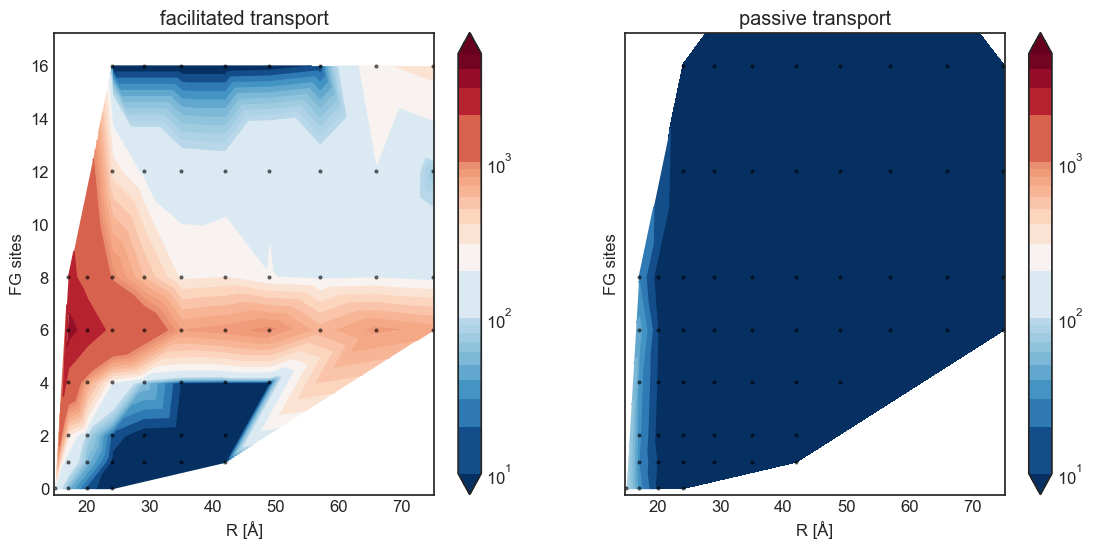

From 10 us


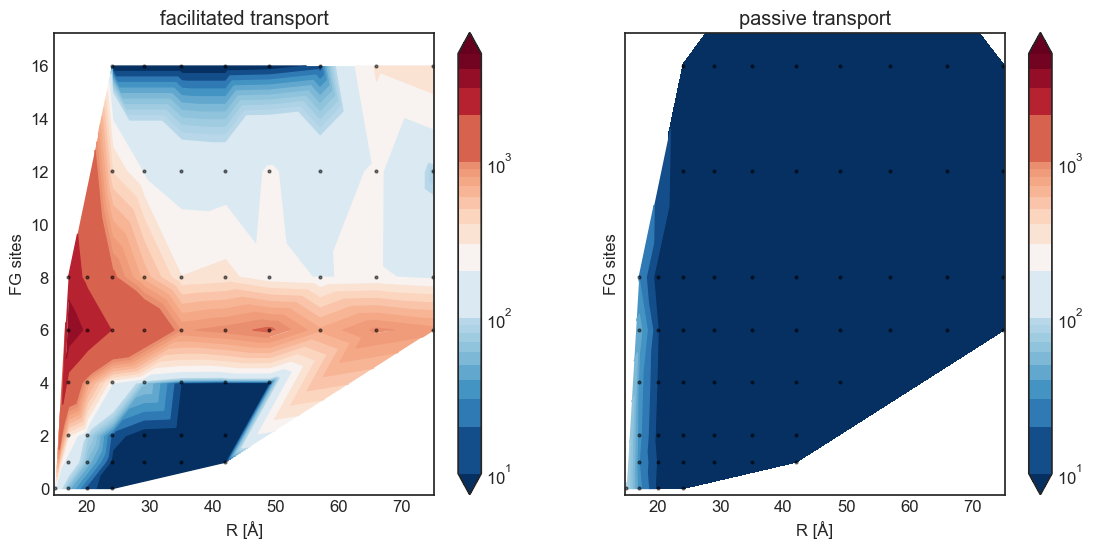

From 15 us


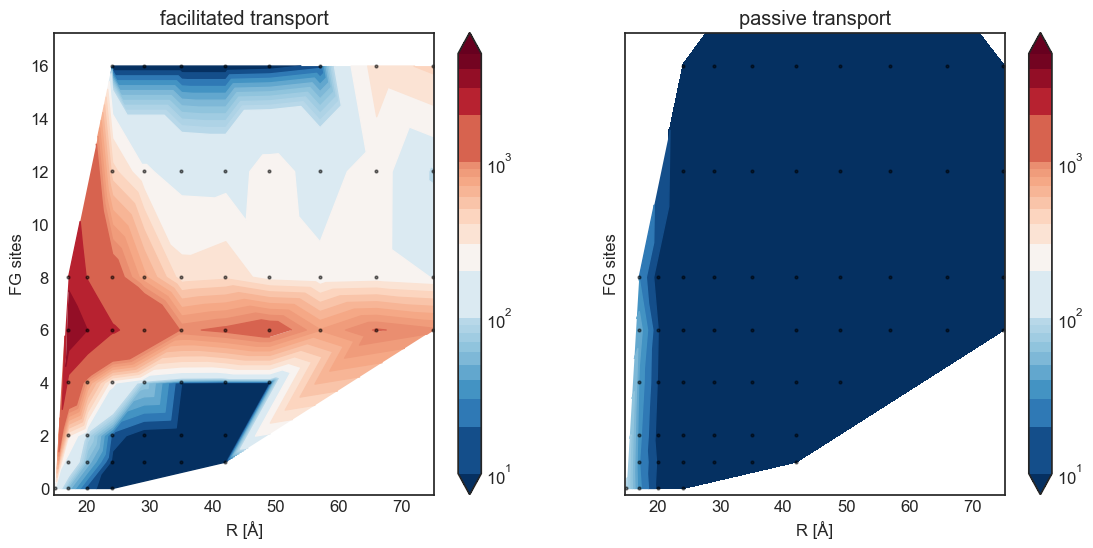

From 20 us


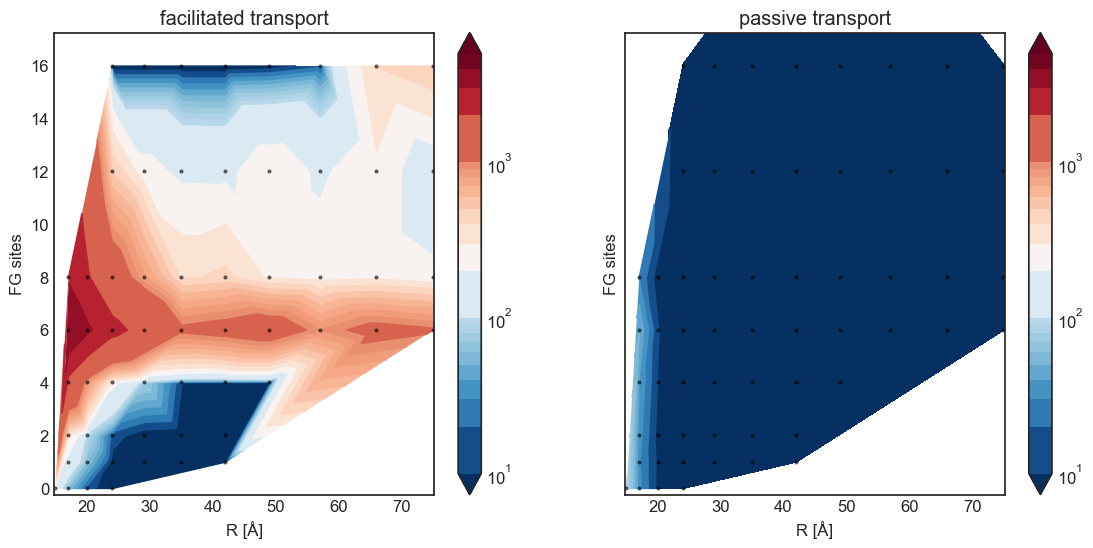

From 25 us


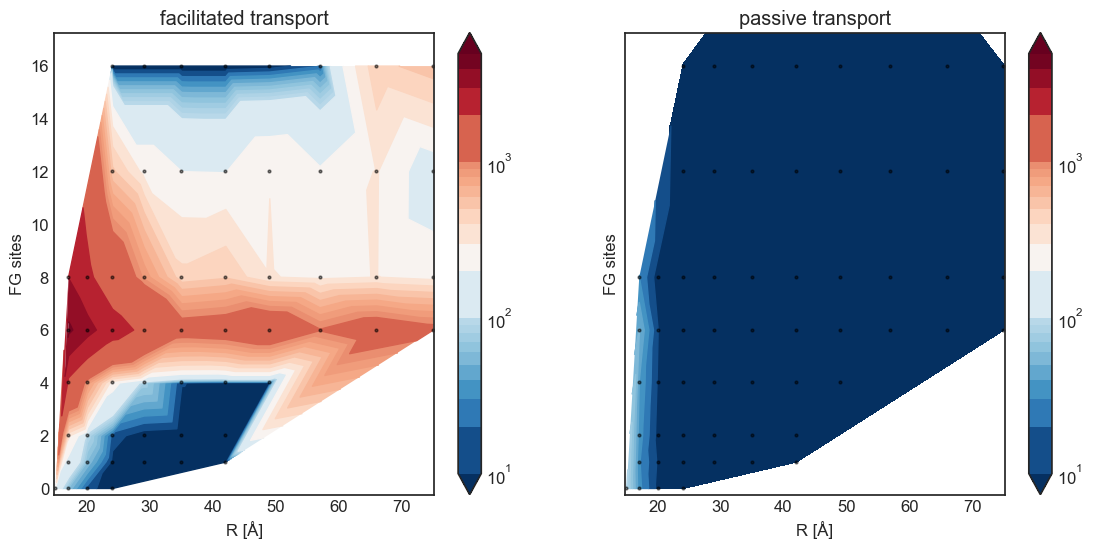

From 30 us


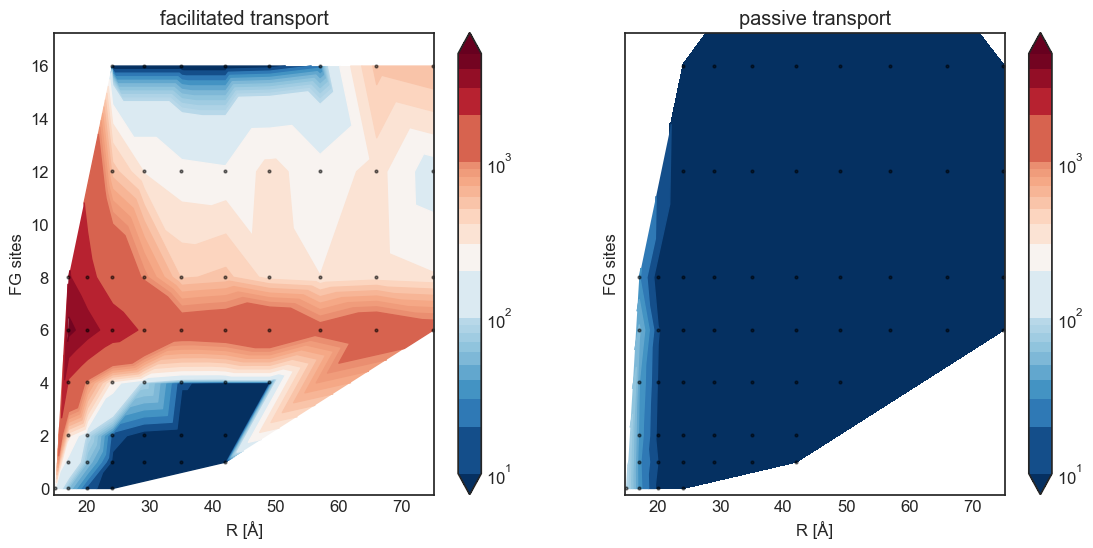

From 35 us


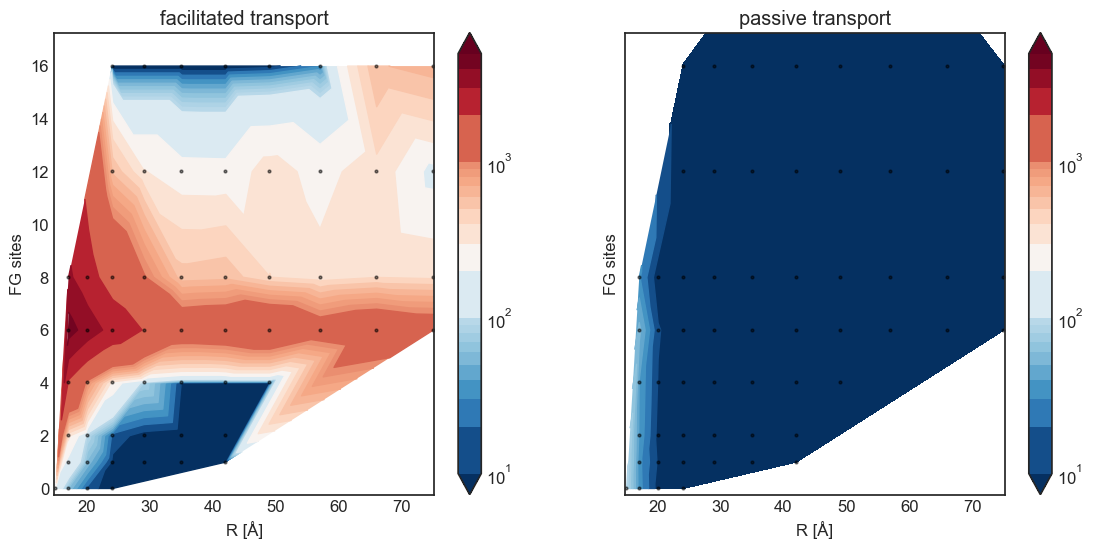

From 40 us


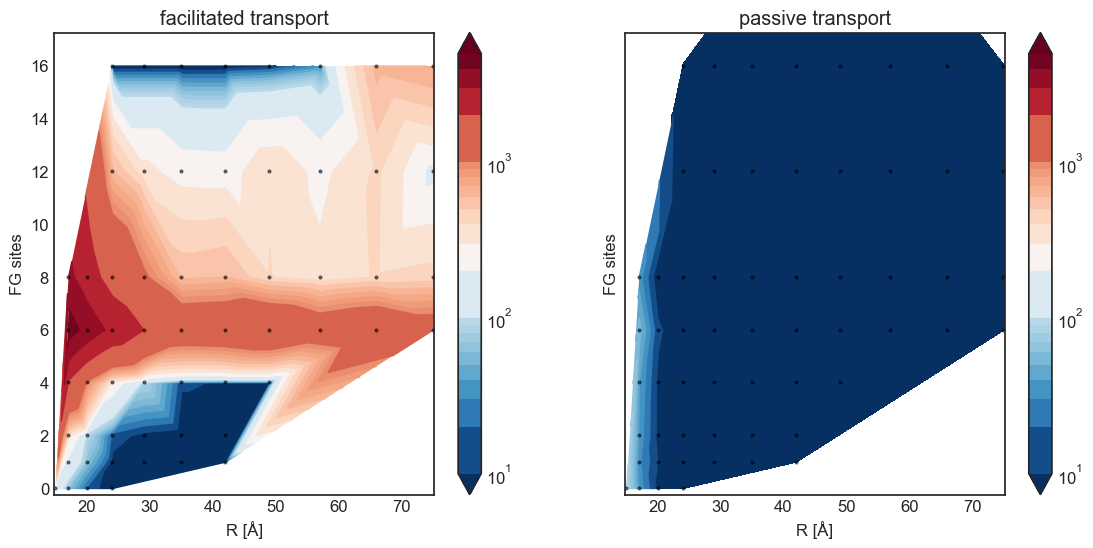

From 45 us


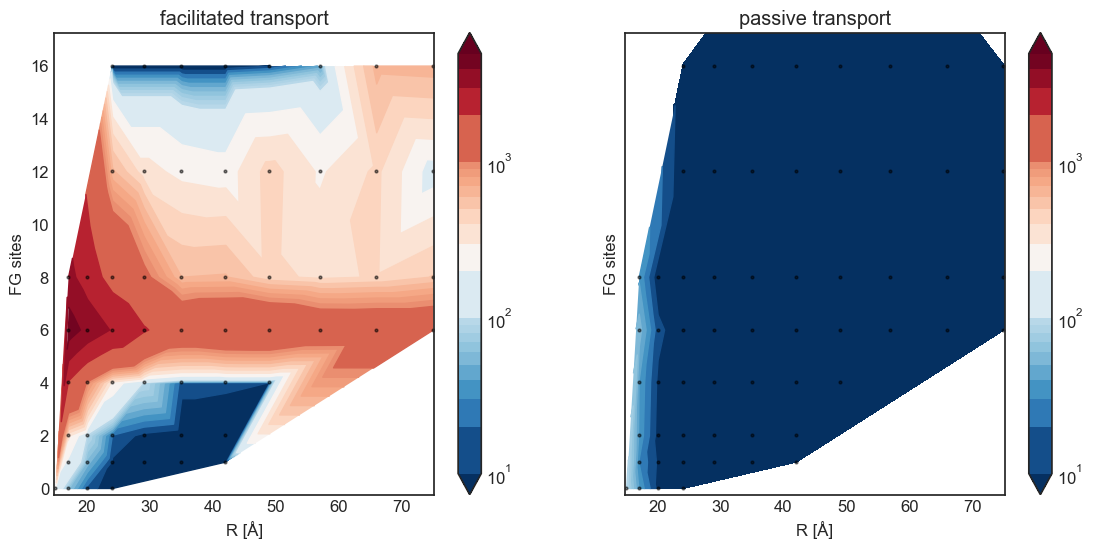

From 50 us


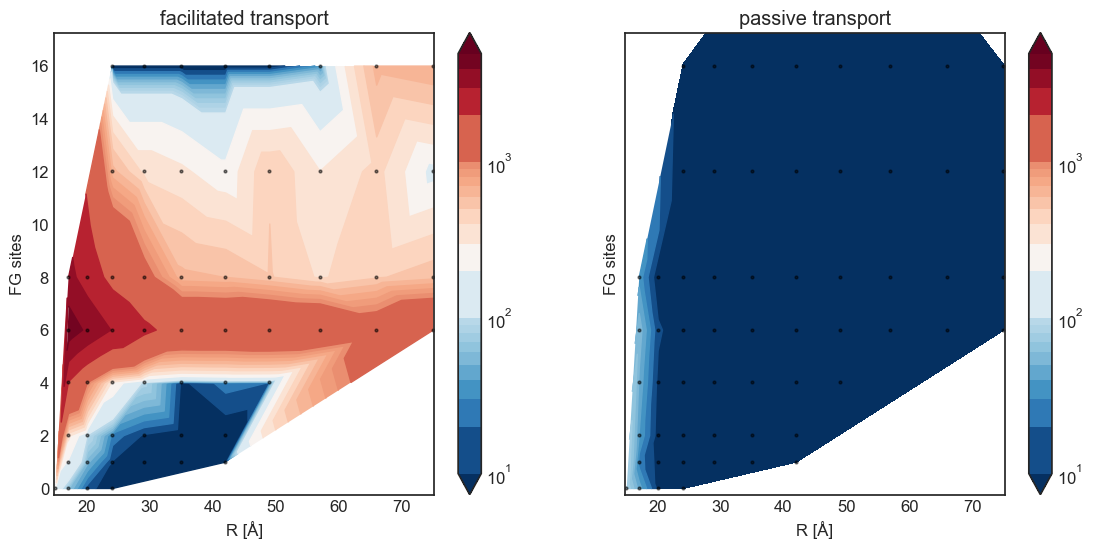

In [7]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import matplotlib.ticker

def convert_radius_A_to_MW_kDa(x):
    return (x/6.6)**3

def plot_slice(slice, label, is_MW=False, is_logz=True, ax=None):
    if ax is None:
        ax= plt.gca()
    if ax is None:
        fig, ax= plt.subplots(1,1,figsize=(6,4))
    x= slice['R']
    if is_MW:
        x= convert_radius_A_to_MW_kDa(x)
    y= slice['n_sites']
    z= (slice['transport_per_sec_per_particle']+0.1)
    if is_logz:
        locator= matplotlib.ticker.LogLocator(base=10.0,
                                              subs=np.arange(1,10)*0.1)
        levels= np.concatenate([
 #                     [0.1],
 #                     np.arange(2,10)*0.1,
 #                     [1.0],                              
 #                     np.arange(2,10)*1.0,
                      [10],                              
                      np.arange(2,10)*10.0, 
                      [100],
                      np.arange(2,10)*100.0,
                      [1000.0, 2000.0, 3000.0, 4000.0, 5000.0]])
    else:
        locator= matplotlib.ticker.MaxNLocator(nbins=256)
        levels=256
    cntr = ax.tricontourf(x, y, z, cmap="RdBu_r", 
                          levels= levels,
                         locator=locator,
                         extend='both')

    for c in cntr.collections:
    #    c.set_edgecolor('none')
    #    c.set_linewidth(0)
        c.set_edgecolor("face")
    cb= plt.colorbar(cntr, ax=ax)   
    #                 format=matplotlib.ticker.LogFormatterMathtext())
    ax.plot(x, y, 'wo', ms=2, alpha=0.5, color='black')
    if is_MW:
        ax.set_xlabel('MW [kDa]')
    else:
        ax.set_xlabel('R [Å]')
    ax.set_ylabel('FG sites')
    ax.set(xlim=(min(x)-0.25, max(x)+0.25), 
                  ylim=(min(y)-0.25, min(max(y),17)+0.25) )
    ax.set_title(label)

def do_transport_analysis(df, from_sec, to_sec):
    ''' plot kap and intrt transport analysis from simulation time from_sec till to_sec '''
    is_from= np.isclose(df['from_sec'], from_sec)
    is_to= np.isclose(df['to_sec'], to_sec)
    is_kap= df['type']=='kap'
    is_sites= df['n_sites']<20
    slice_kap= df[is_kap & is_from & is_to & is_sites]
    is_inert= df['type']=='inert'
    slice_inert= df[is_inert & is_from & is_to]
    fig, axes= plt.subplots(1,2, sharey=True, figsize=(13.5,6))
    for is_logz in [True]:
        plot_slice(slice_kap, "facilitated transport", is_logz=is_logz, ax=axes[0], is_MW=False)
        plot_slice(slice_inert, "passive transport", is_logz=is_logz, ax=axes[1], is_MW=False)
    #plt.subplots_adjust(hspace=0.5)
    plt.show()
    
#font = {'size'   : 14}
#matplotlib.rc('font', **font)
#matplotlib.rc('xtick', labelsize=14) 
#matplotlib.rc('ytick', labelsize=14) 
#plt.rcParams.update({'font.size': 14})
plt.style.use('seaborn-white')
font = {'size'   : 12}
matplotlib.rc('font', **font)
is_map_from= True
if is_map_from:
    to_sec= 55e-6
    for from_sec in np.arange(5e-6, to_sec, 5e-6):
        print("From {:.0f} us".format(from_sec*1e6))
        do_transport_analysis(df, from_sec, to_sec)
else:
    from_sec= 10e-6
    for to_sec in np.arange(from_sec + 5e-6, 36e-6, 10e-6):
        print("To {:.0f} us".format(to_sec*1e6))
        do_transport_analysis(df, from_sec, to_sec)


In [8]:
import plotnine as p9
import scipy.special

def my_formatter(x):
    try:
        x_as_R= int(x)
        return "{:} A".format(x_as_R)
    except ValueError as e:
        pass
    try:
        x_as_us= float(x)*1e6
        if x_as_us<1000:
            return "{:.0f} $\mu s$".format(x_as_us)
    except ValueError as e:
        pass
    return x


def poly(x, degree=1):
    """
    Fit Polynomial

    These are non orthogonal factors, but it may not matter if
    we only need this for smoothing and not extrapolated
    predictions.
    """
    d = {}
    for i in range(degree+1):
        if i == 1:
            d['x'] = x
        else:
            d[f'x**{i}'] = np.power(x, i)
    return pd.DataFrame(d)

def power(x):
    """
    Fit Poweer

    These are non orthogonal factors, but it may not matter if
    we only need this for smoothing and not extrapolated
    predictions.
    """
    d={}
    d['logx']= np.log(x)
    d[f'x**{0}']= 1
    return pd.DataFrame(d)

/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/scales/scales.py:50: PlotnineWarning: Scale for 'y' is already present.
Adding another scale for 'y',
which will replace the existing scale.

/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/stats/stat_smooth.py:210: PlotnineWarning: Smoothing requires 2 or more points. Got 1. Not enough points for smoothing. If this message a surprise, make sure the column mapped to the x aesthetic has the right dtype.
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1716: RuntimeWarning: divide by zero encountered in scalar divide
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 953 rows containing missing values.


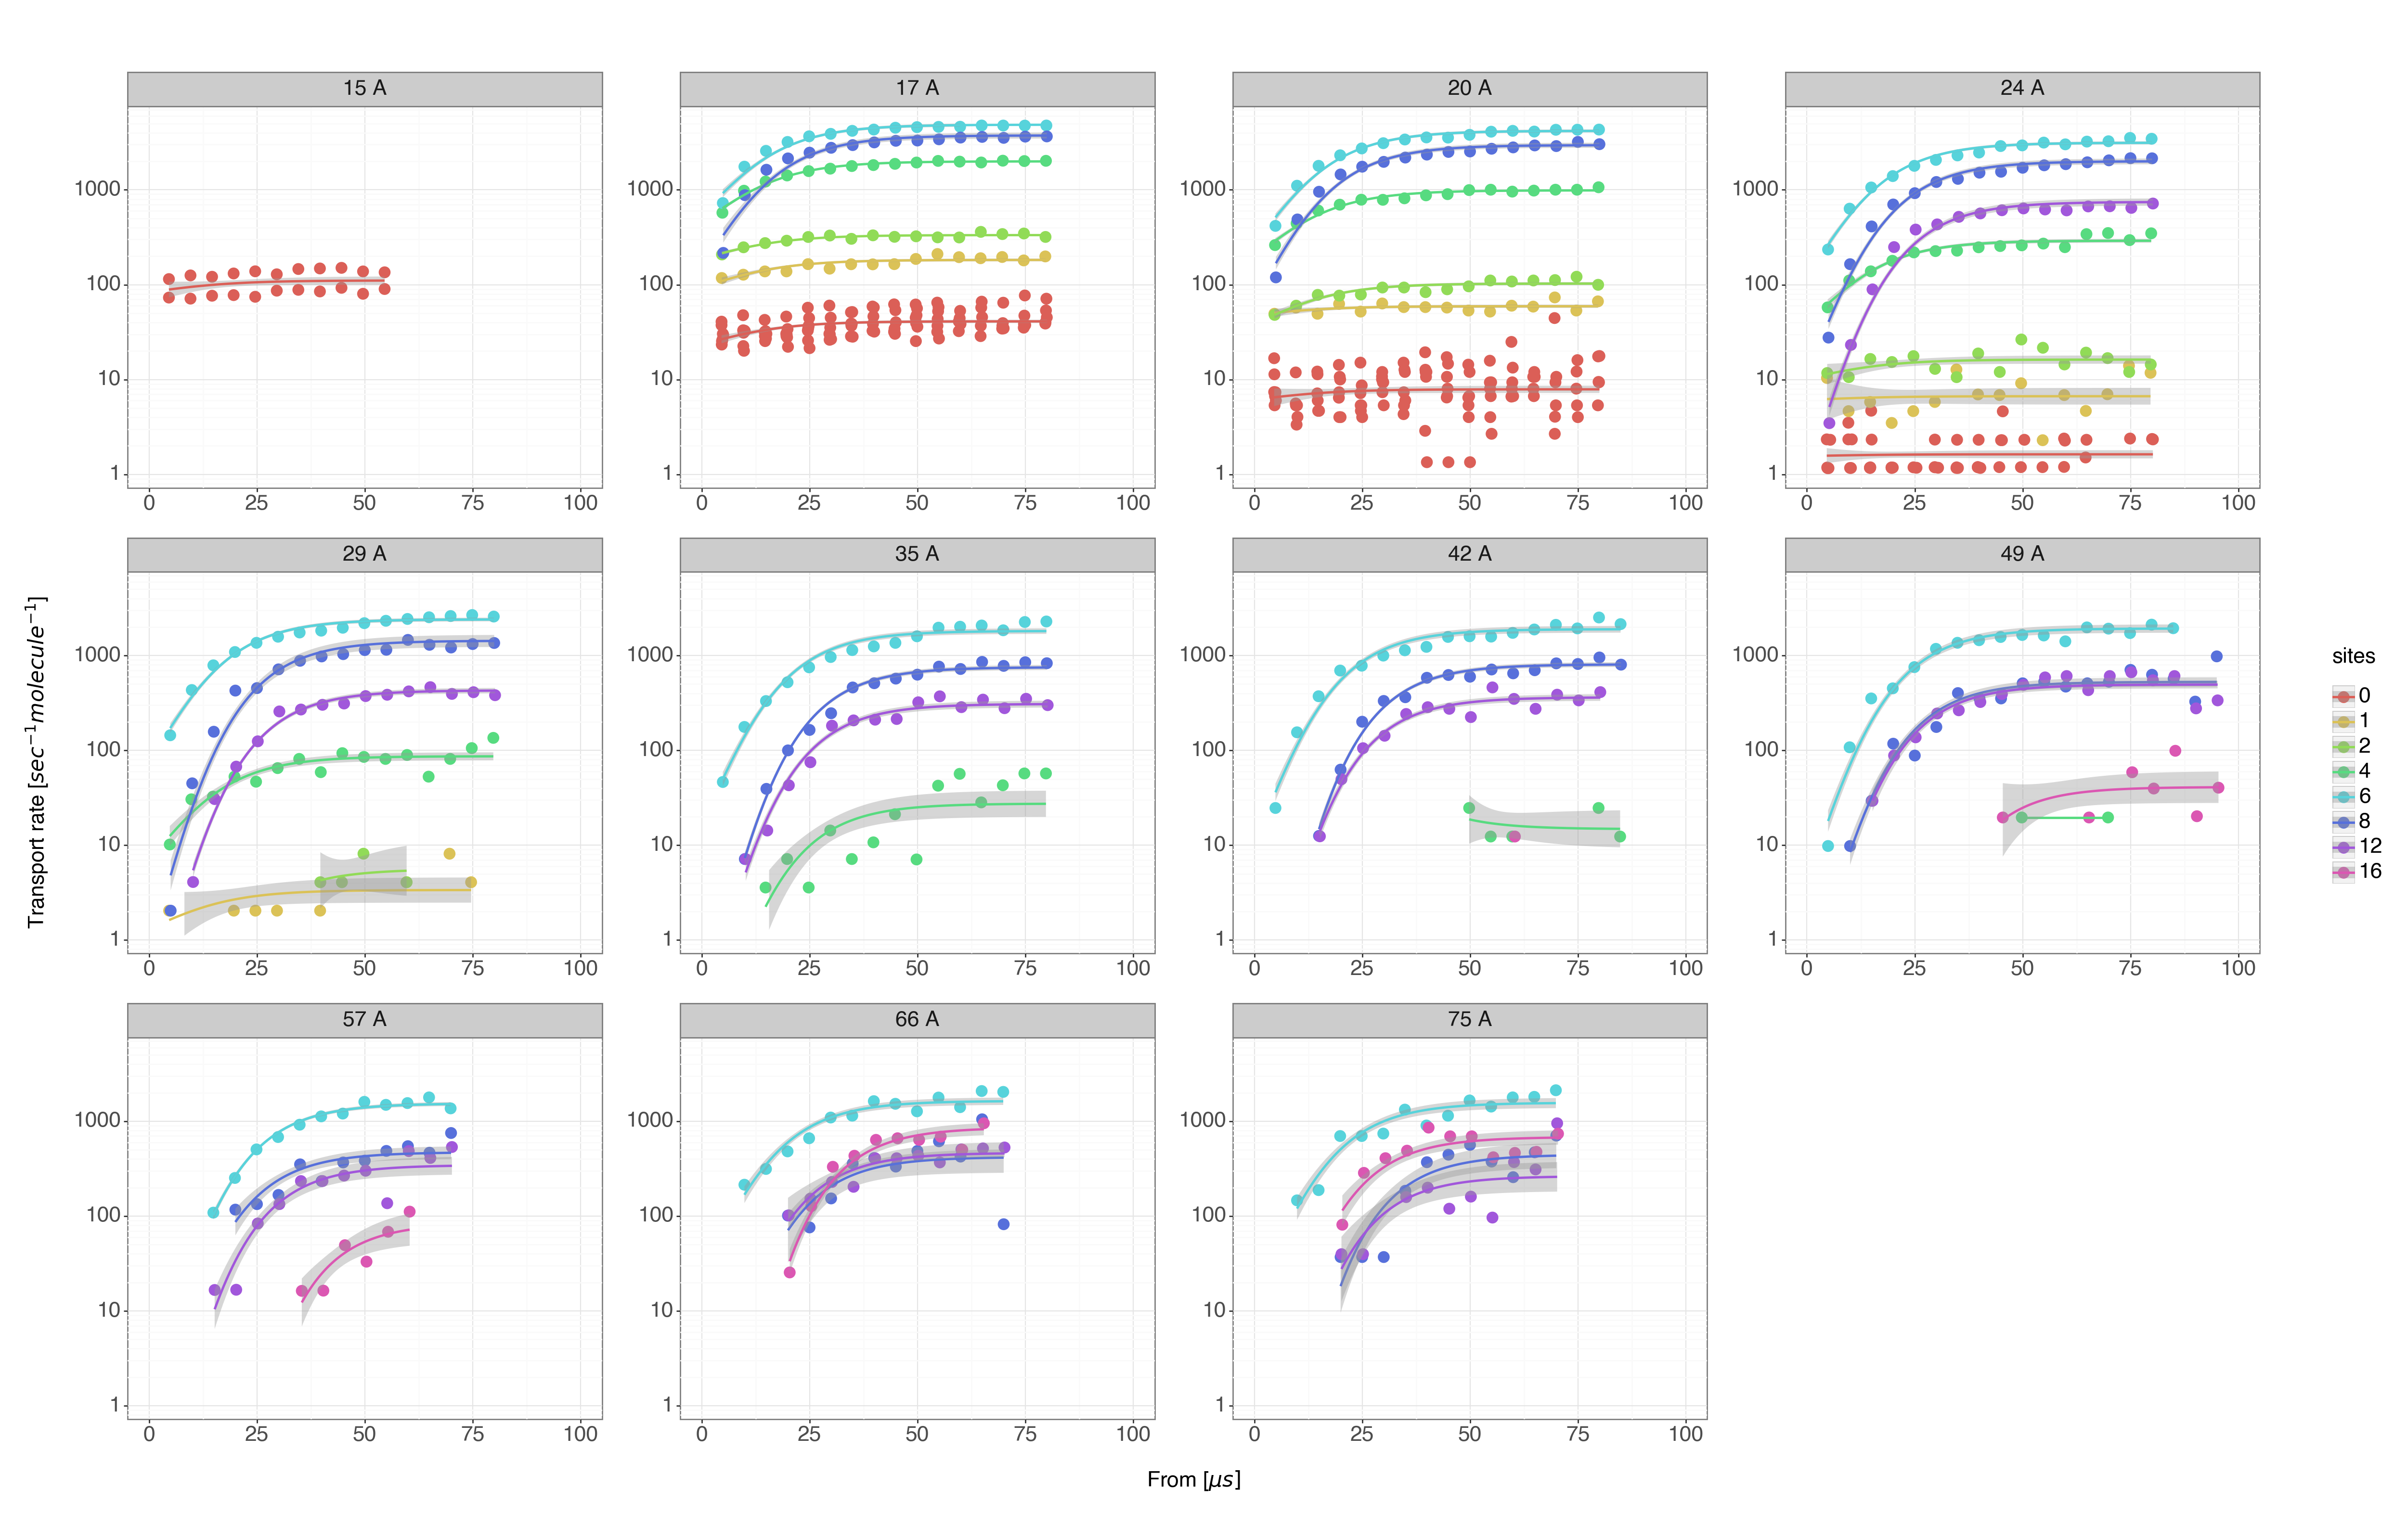

<Figure Size: (2500 x 1600)>

In [9]:
#is_from= df['to_sec']>=80e-6
is_kap= df['type']=='kap'
is_inert= df['type']=='inert'
is_sites= (df['n_sites']>=0) & (df['n_sites']<20)
is_5_interval= np.isclose(df['to_sec']-df['from_sec'], 5e-6)
slice= df[((is_kap & is_sites) | is_inert) & is_5_interval  ] # is_from
#display(slice.head(1)['type'])
p9.options.figure_size=(25,16)
aes= p9.aes(x='from_sec*1e6 + 0.05*n_sites - 0.4', 
                #y='transport_per_sec_per_particle+0.1',
#                          ymin='transport_per_sec_per_particle-1.96*transport_per_sec_per_particle_sem',
#                          ymax='transport_per_sec_per_particle+1.96*transport_per_sec_per_particle_sem',
            y=   'transport_5us_per_sec_per_particle+0.01',
            ymin='transport_5us_per_sec_per_particle_95low',
            ymax='transport_5us_per_sec_per_particle_95high',
            width=.35e-6,
            color='factor(n_sites_own)')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_point(size=4)
# + p9.geom_errorbar(size=0.75,
#                   alpha=0.5)
  + p9.xlab("From [$\mu s]$")
  + p9.ylab("Transport rate [$sec^{-1}molecule^{-1}$]")
# + p9.ggtitle("R={:} A".format(slice_kap.iloc[0]["R"]))
 + p9.labs(color="sites")
 + p9.theme_bw()
#  + p9.theme_xkcd()
 + p9.theme(text=p9.element_text(size=16))
 + p9.stat_smooth(method='lm',
      formula='y ~ scipy.special.expit(x/10.0)', #'y ~ np.log(x)',
#    formula='y ~ (a/(1+np.exp(-x)))', # n.(x)/(1+x)',
     span=0.10,     se=True,     level=0.8,     size=1)
# + p9.geom_smooth(method = 'auto')
# + scale_color_brewer(palette="Blues",drop=True, type='div')
 #+ p9.facet_grid("to_sec ~ R",
 #                labeller= my_formatter,
 #               scales="free")
 + p9.facet_wrap("R", labeller= my_formatter, scales="free")
 +p9.ylim(0.0,5000.0)
  + p9.scale_y_log10(limits=(1.1,5000.0))
# + p9.scale_x_continuous(labels= lambda x:["{:.0f}".format(xx) for xx in x])
  +p9.xlim(0.0,100.0)

)

/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10


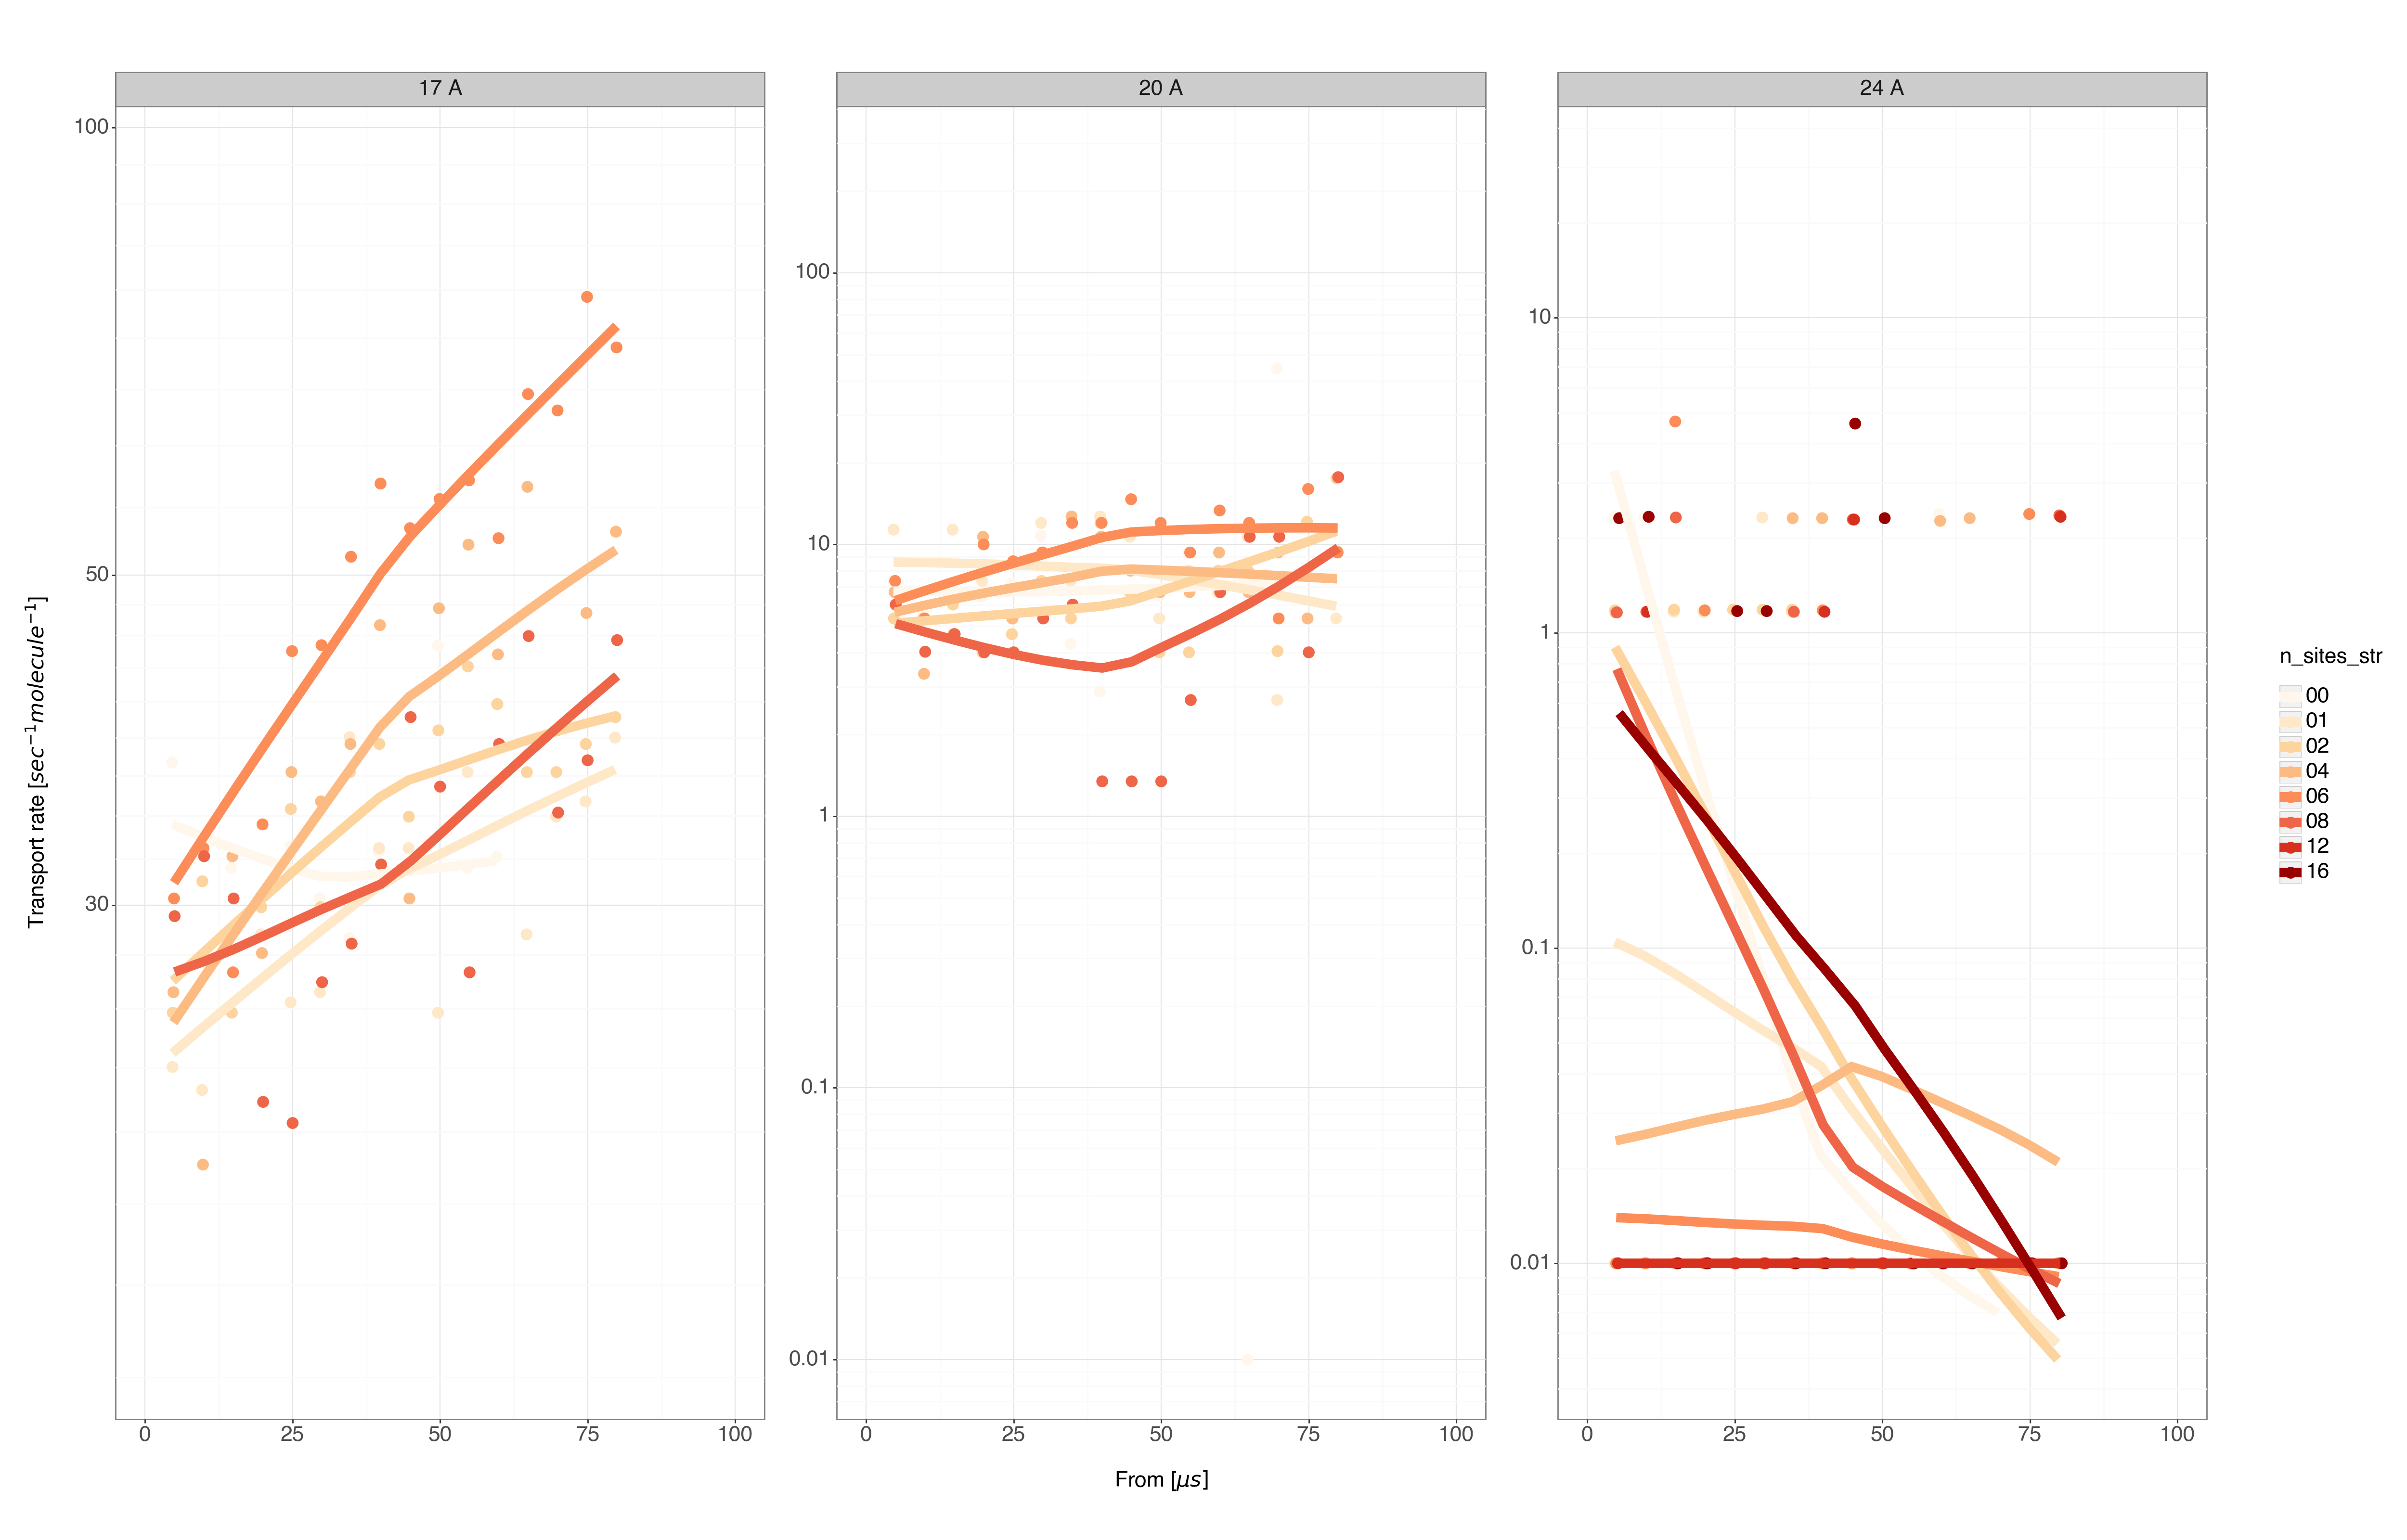

<Figure Size: (2500 x 1600)>

In [10]:
#is_from= df['to_sec']>=80e-6
is_kap= df['type']=='kap'
is_inert= df['type']=='inert'
df['n_sites_str'] = [f"{x:02.0f}" for x in df['n_sites']]
is_sites= (df['n_sites']>=0) & (df['n_sites']<30)
is_5_interval= np.isclose(df['to_sec']-df['from_sec'], 5e-6)
is_R = (df['R'] < 25) & (df['R'] >= 17)
slice= df[(is_inert) & is_5_interval & is_sites & is_R] # is_from
#display(slice.head(1)['type'])
p9.options.figure_size=(25,16)
aes= p9.aes(x='from_sec*1e6 + 0.05*n_sites - 0.4', 
                #y='transport_per_sec_per_particle+0.1',
#                          ymin='transport_per_sec_per_particle-1.96*transport_per_sec_per_particle_sem',
#                          ymax='transport_per_sec_per_particle+1.96*transport_per_sec_per_particle_sem',
            y=   'transport_5us_per_sec_per_particle+0.01',
            ymin='transport_5us_per_sec_per_particle_95low',
            ymax='transport_5us_per_sec_per_particle_95high',
            width=.35e-6,
            color='n_sites_str') #factor(n_sites_own)')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_point(size=4)
 #  + p9.geom_line(size=4)
# + p9.geom_errorbar(size=0.75,
#                   alpha=0.5)
  + p9.xlab("From [$\mu s]$")
  + p9.ylab("Transport rate [$sec^{-1}molecule^{-1}$]")
# + p9.ggtitle("R={:} A".format(slice_kap.iloc[0]["R"]))
# + p9.labs(color="sites")
 + p9.theme_bw()
#  + p9.theme_xkcd()
 + p9.theme(text=p9.element_text(size=16))
# + p9.stat_smooth(method='lm',
#      formula='y ~ scipy.special.expit(x/10.0)', #'y ~ np.log(x)',
#    formula='y ~ (a/(1+np.exp(-x)))', # n.(x)/(1+x)',
#     span=0.10,     se=True,     level=0.8,     size=1)
 + p9.geom_smooth(method = 'auto', span=1.0, se=False, size=4)
# + scale_color_brewer(palette="Blues",drop=True, type='div')
 #+ p9.facet_grid("to_sec ~ R",
 #                labeller= my_formatter,
 #               scales="free")
 + p9.facet_wrap("R", labeller= my_formatter, scales="free")
# +p9.ylim(0.0,5000.0)
  + p9.scale_y_log10()#limits=(0.5,200.0))
# + p9.scale_x_continuous(labels= lambda x:["{:.0f}".format(xx) for xx in x])
  +p9.xlim(0.0,100.0)
   +p9.scales.scale_color_brewer(type='seq',
                         palette="OrRd", 
                         aesthetics="color",
                              direction=1)


)

/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1716: RuntimeWarning: divide by zero encountered in scalar divide
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1716: RuntimeWarning: divide by zero encountered in scalar divide


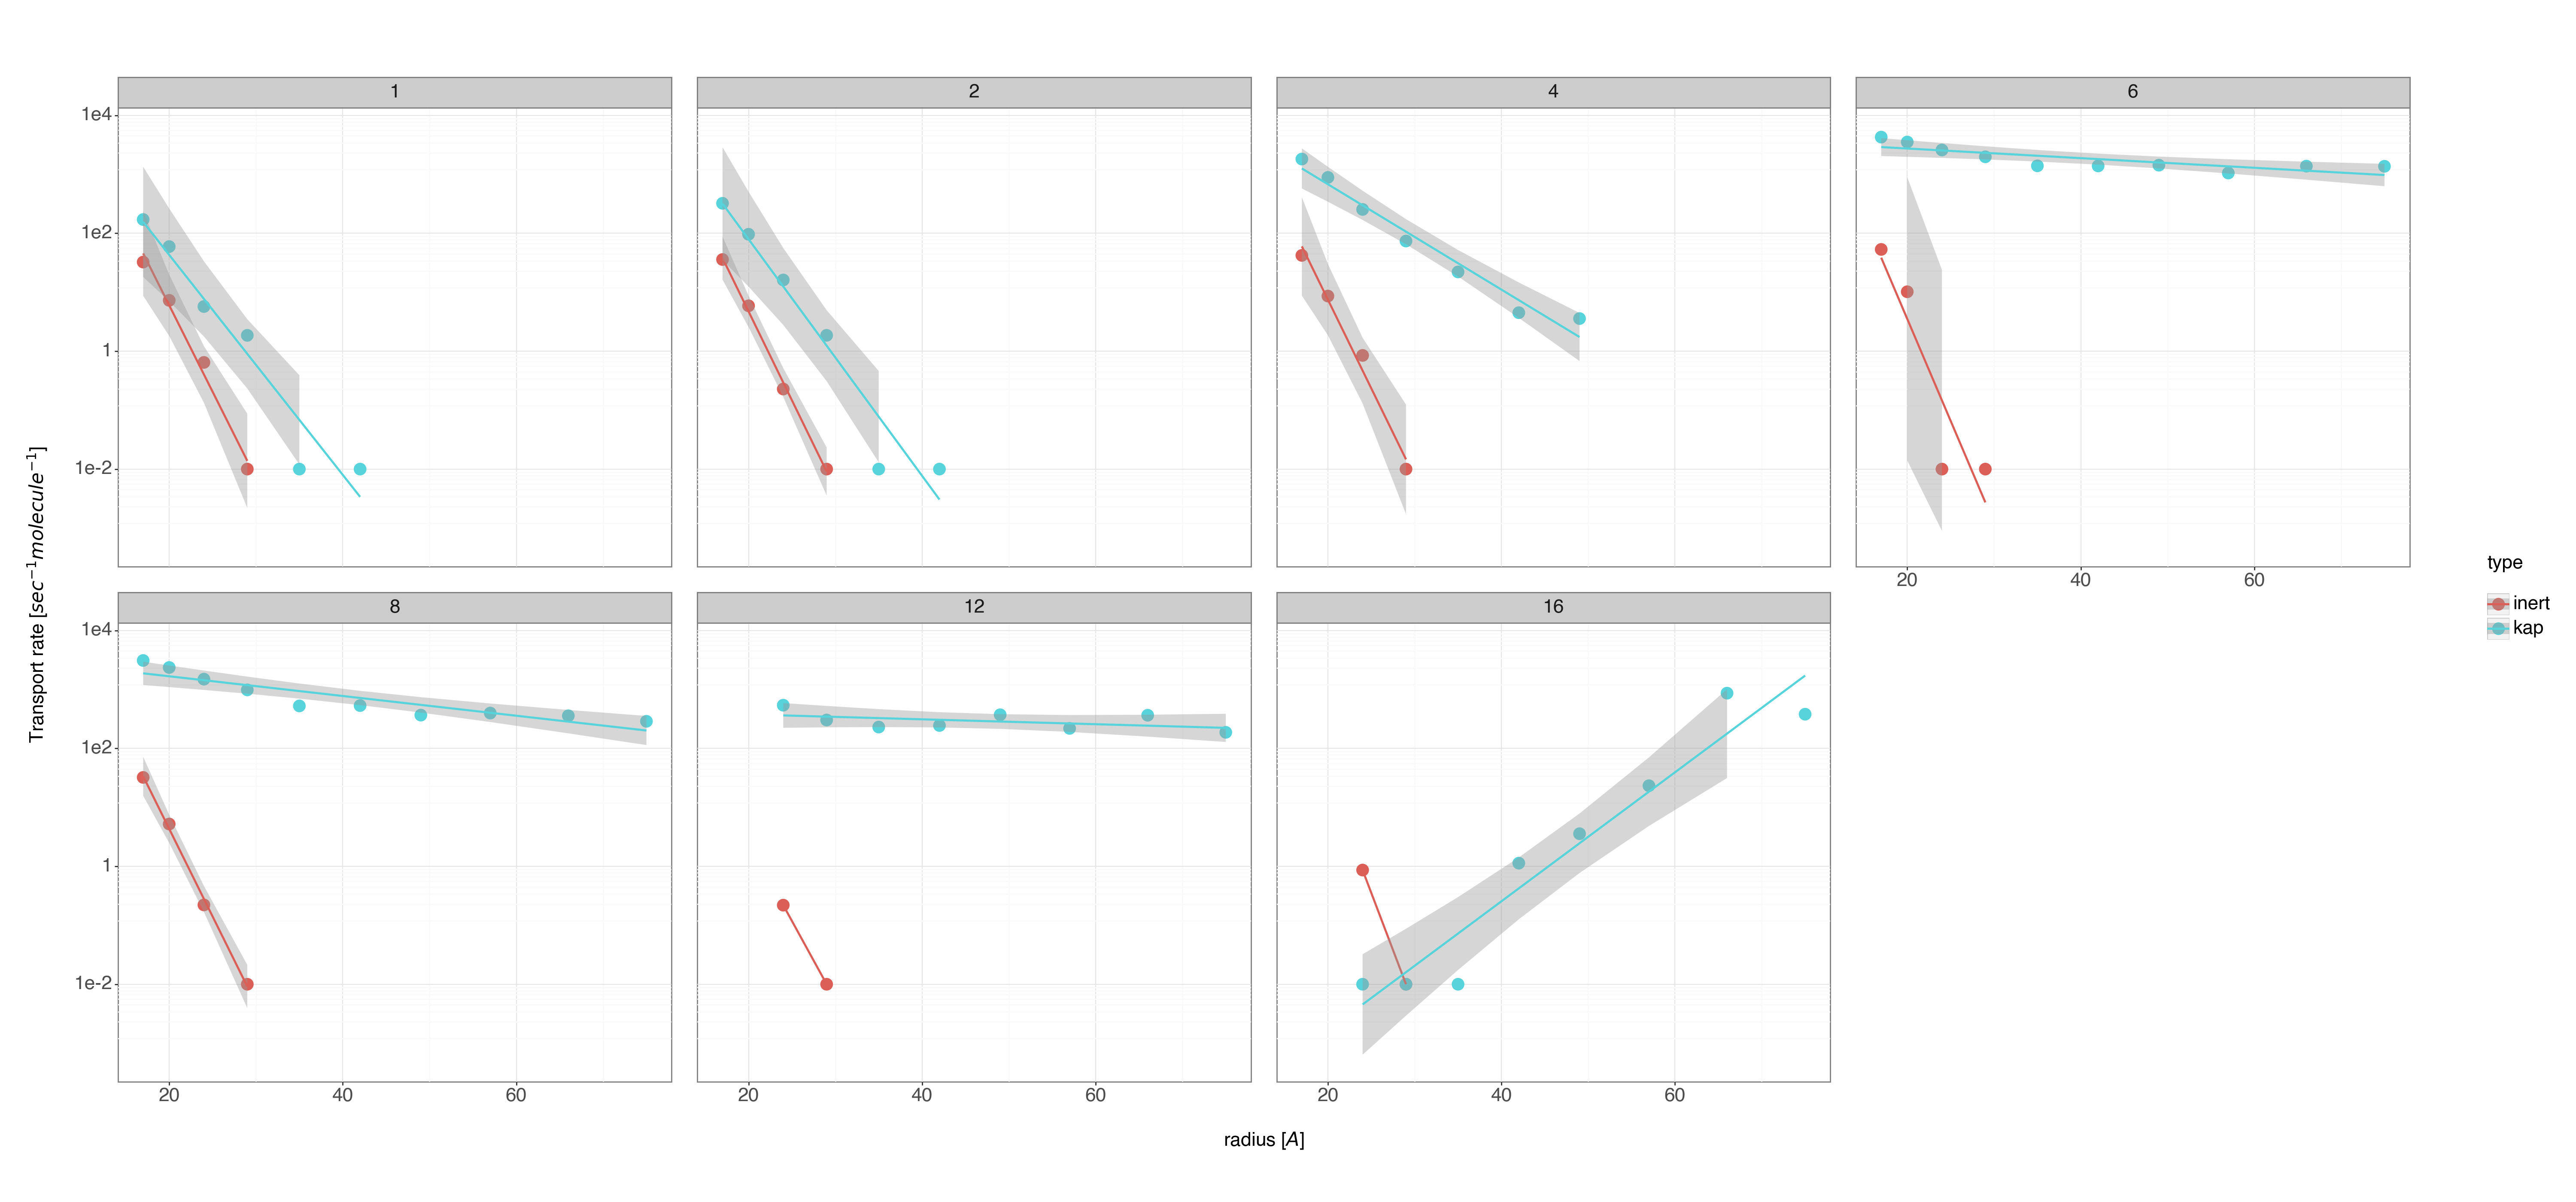

<Figure Size: (3000 x 1400)>

In [11]:
import plotnine as p9
import scipy.special

#diffuser='inert'    
is_from= np.isclose(df['to_sec'], 75e-6)
is_to= np.isclose(df['from_sec'], 20e-6)
#is_kap= df['type']==diffuser
is_sites= (df['n_sites']>=1) & (df['n_sites']<17)
is_small_inert= (df['type']=='inert') & (df['R']<31)
is_kap= (df['type']=='kap')
is_type= is_kap | is_small_inert
slice= df[is_from & is_to & is_sites & is_type]
p9.options.figure_size=(30,14)
aes= p9.aes(x='R', 
                #y='transport_per_sec_per_particle+0.1',
#                          ymin='transport_per_sec_per_particle-1.96*transport_per_sec_per_particle_sem',
#                          ymax='transport_per_sec_per_particle+1.96*transport_per_sec_per_particle_sem',
            y=   'transport_per_sec_per_particle+0.01',
            ymin='transport_per_sec_per_particle_95low',
            ymax='transport_per_sec_per_particle_95high',
            color='type')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_point(size=5)
# + p9.geom_errorbar(size=1, width=3)
  + p9.xlab("radius [$A$]")
  + p9.ylab("Transport rate [$sec^{-1}molecule^{-1}$]")
 + p9.theme_bw()
#  + p9.theme_xkcd()
 + p9.theme(text=p9.element_text(size=16))
 + p9.stat_smooth(method='lm',
      formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
     span=0.10,     se=True,     level=0.95,     size=1)
 + p9.facet_wrap("n_sites", ncol=4)
#  + p9.scale_x_log10(limits=(15,50))
  + p9.scale_y_log10(limits=(0.5e-3,6000.0))
 
)

#plt.show()

In [12]:
import plotnine as p9
import scipy.special

def get_exponent_format(numbers):
    print(numbers)
    logs = [int(x) for x in np.round(np.log10(numbers))]
    deltas = np.abs(logs-np.log10(numbers))
    return [(r"$10^{{{:d}}}$".format(log) if delta < 0.01 else number) \
                for number, log, delta in zip(numbers, logs, deltas)]

IS_INERT=False
print(IS_INERT)
#diffuser='inert'    
is_from= np.isclose(df['to_sec'], 75e-6)
is_to= np.isclose(df['from_sec'], 10e-6)
#is_kap= df['type']==diffuser
is_sites= (df['n_sites']>=0) & (df['n_sites']<(9 if IS_INERT else 17))
is_inert= (df['type']=='inert') & (df['R']<29)
is_kap= (df['type']=='kap')
is_20 = df['R']==20
df['R_as_str'] = [f"{x}" for x in df['R']]
is_type=(is_inert if IS_INERT else is_kap & is_20)
slice= df[is_from & is_to & is_sites & is_type]
p9.options.figure_size=(6,4)
SCALING_FACTOR_FROM_PASSIVE_EXP = 200.0
aes= p9.aes(x='n_sites', 
            y=   '(transport_per_sec_per_particle_per_uM/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01)',
            ymin='(transport_per_sec_per_particle_per_uM_95low/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01)',
            ymax='(transport_per_sec_per_particle_per_uM_95high/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01)',
            color='R_as_str')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_point(size=8)
  + p9.geom_errorbar(size=1, width=0.6)
  + p9.xlab("number of sites")
  # add centered ylabel 
  + p9.ylab("NPC permeability\n[molecules/sec/$\mu$M/NPC]")
  + p9.theme_bw()
#  + p9.theme_xkcd()
 + p9.theme(text=p9.element_text(size=16),
               panel_border = p9.element_blank(),
           axis_line = p9.element_line(colour = "black"),)
          #     panel_grid=p9.element_blank())
# + p9.stat_smooth(method='lm',
#      formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
#     span=0.10,     se=True,     level=0.95,     size=1)
# + p9.facet_wrap("R", ncol=1)
#  + p9.scale_x_log10(limits=(15,50))
  + p9.scale_y_log10(limits=(0.5,10.0) if IS_INERT else [0.25, 100.0], 
                     labels=get_exponent_format)
 +p9.scales.scale_color_brewer(type='qual',
                         palette="Dark2", 
                         aesthetics="color",
                              direction=-1)
).save(filename=f"transport_stats_by_number_of_sites_R20.png", dpi=300)
#plt.savefig(f"transport_stats_by_number_of_sites_R20.png", dpi=300)


False
[  1.  10. 100.]


/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 4 in image.
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: transport_stats_by_number_of_sites_R20.png


[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]


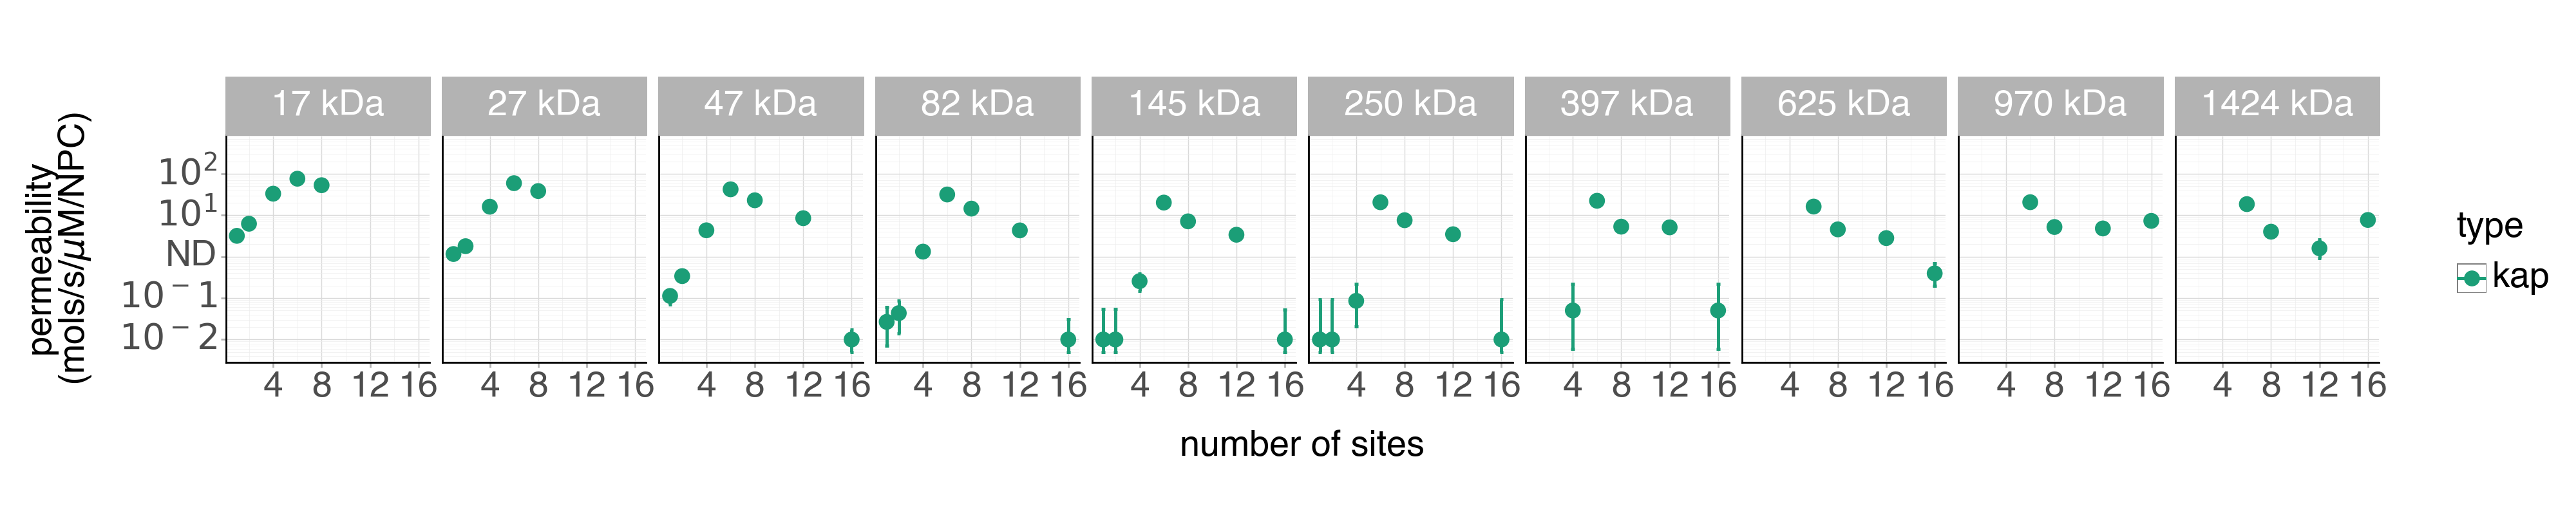

<Figure Size: (2000 x 400)>

In [13]:
import plotnine as p9
import scipy.special

def get_exponent_format(number):
    print(number)
    # if number is 1, return "ND"ArithmeticError
    return ["ND" if x==1 else "$10^{:d}$".format(int(round(np.log10(x)))) for x in number]
    
#diffuser='inert'    
is_from= np.isclose(df['to_sec'], 60e-6)
is_to= np.isclose(df['from_sec'], 10e-6)
#is_kap= df['type']==diffuser
is_sites= (df['n_sites']>=1) & (df['n_sites']<17)
is_small_inert= (df['type']=='inert') & (df['R']<31)
is_kap= (df['type']=='kap')
is_R = df['R']<100
is_type= (is_kap) & is_R
slice= df[is_from & is_to & is_sites & is_type]
p9.options.figure_size=(20,4)
SCALING_FACTOR_FROM_PASSIVE_EXP = 200.0
aes= p9.aes(x='n_sites', 
            y=   'transport_per_sec_per_particle_per_uM/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01',
            ymin='transport_per_sec_per_particle_per_uM_95low/SCALING_FACTOR_FROM_PASSIVE_EXP+0.005',
            ymax='transport_per_sec_per_particle_per_uM_95high/SCALING_FACTOR_FROM_PASSIVE_EXP',
            color='type')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_point(size=4)
 + p9.geom_errorbar(size=1, width=0.3)
  + p9.xlab("number of sites")
  + p9.ylab("   permeability\n(mols/s/$\mu$M/NPC)")
  + p9.theme(axis_text_y=p9.element_text(margin={'r': 14}, hjust=0.5))
#  + p9.theme_bw()
 # + p9.theme_xkcd()
 +p9.theme_light()
 + p9.theme(text=p9.element_text(size=20),
               panel_border = p9.element_blank(),
           axis_line = p9.element_line(colour = "black"),)
          #     panel_grid=p9.element_blank())
# + p9.stat_smooth(method='lm',
#      formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
#     span=0.10,     se=True,     level=0.95,     size=1)
 + p9.facet_wrap("MW_kDa", ncol=10, 
                 labeller=lambda x: "{:.0f} kDa".format(float(x)))
 # tight facets
  + p9.theme(panel_spacing_x=0.005)
 #+ p9.facet_wrap("MW_kDa", ncol=10)
#  + p9.scale_x_log10(limits=(15,50))
  + p9.scale_y_log10(limits=(0.005,500.0), labels=get_exponent_format)
 +p9.scales.scale_color_brewer(type='qual',
                         palette="Dark2", 
                         aesthetics="color",
                              direction=-1)
 # change y tick label of 10^0 to "ND"
 
)

#plt.show()

Slope confidence interval: (-6.501964874426697, 0.1773606697576522)
Intercept confidence interval: (-0.7886840635053813, 8.664722013585944)
Slope -3.1623021023345226
Intercept 3.938018975040281
Slope confidence interval: (-3.7096190032152285, -2.2802549087713957)
Intercept confidence interval: (3.2076693582621134, 5.236489172323108)
Slope -2.994936955993312
Intercept 4.222079265292611
Slope confidence interval: (-3.213198567476762, -2.61390590386638)
Intercept confidence interval: (3.9527787937207024, 4.810385606334524)
Slope -2.913552235671571
Intercept 4.381582200027613
Slope confidence interval: (-2.2363043284141195, -2.0502471800713744)
Intercept confidence interval: (4.051995528013747, 4.370714743637763)
Slope -2.143275754242747
Intercept 4.211355135825755
Slope confidence interval: (-0.4346871136438586, -0.30670004098528825)
Intercept confidence interval: (2.166078469477504, 2.4171769964221856)
Slope -0.3706935773145734
Intercept 2.291627732949845
Slope confidence interval: (-0.7

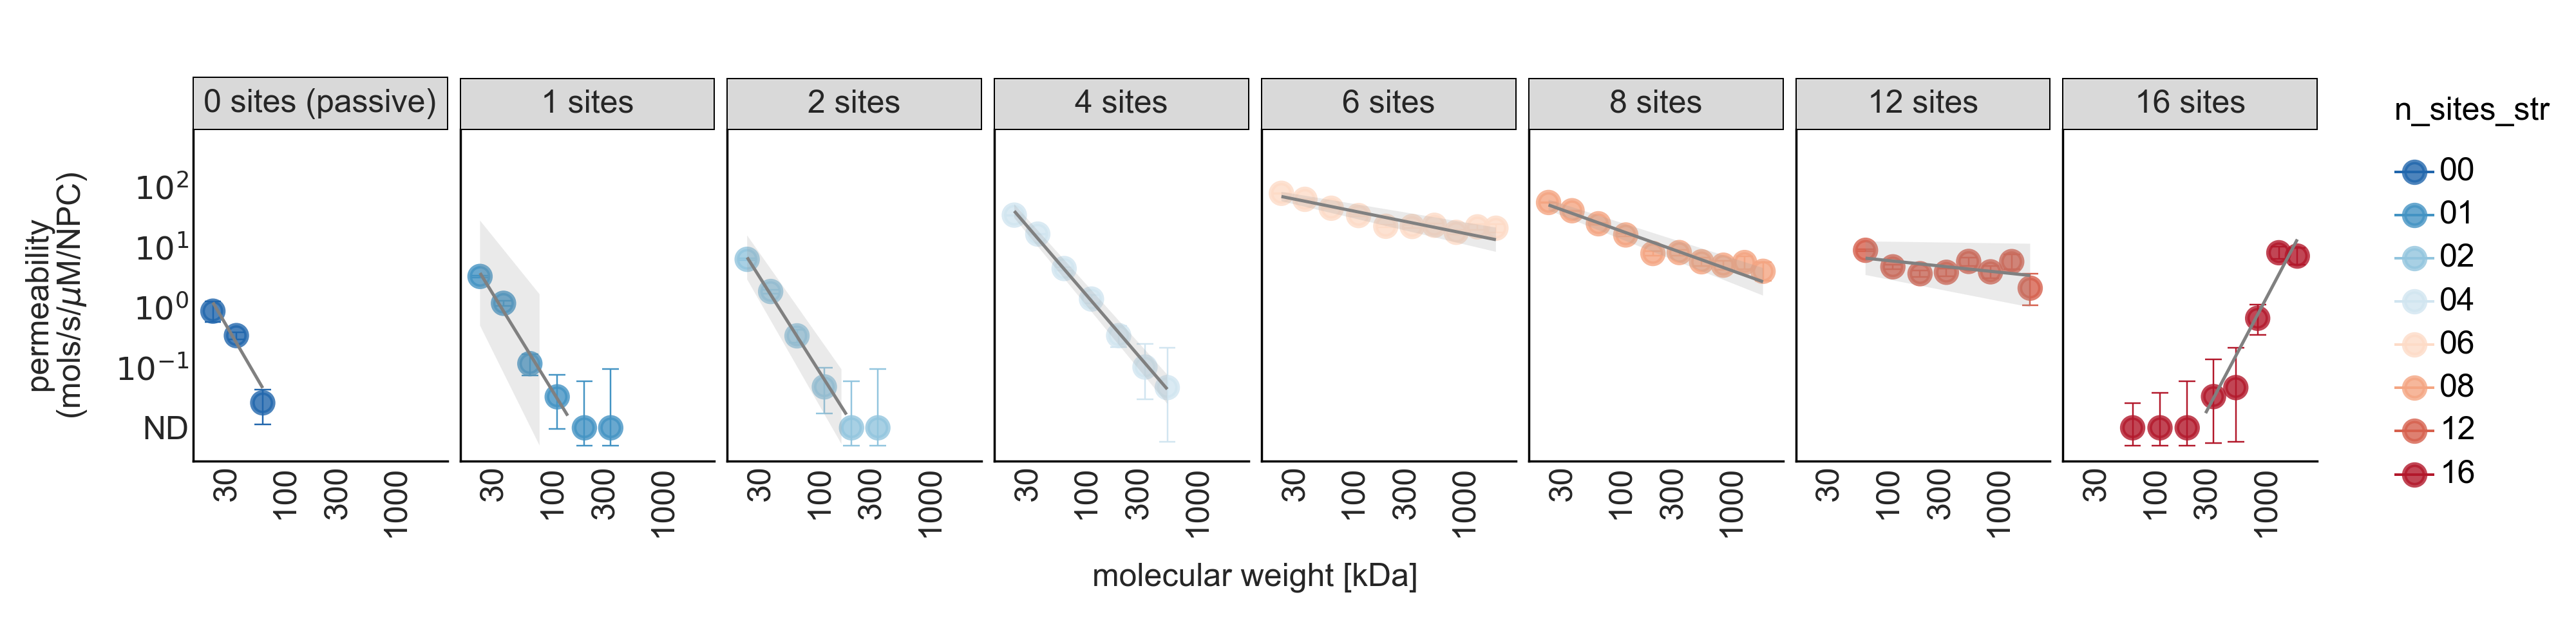

<Figure Size: (2000 x 500)>

In [20]:
import plotnine as p9
import plotnine.utils
import scipy.special
import plotnine.stats.smoothers
import scipy.stats 

def get_exponent_format(number):
    print(number)
    # if number is 1, return "ND"ArithmeticError
    return ["ND" if np.isclose(x,0.01) else "$10^{{{:d}}}$".format(int(round(np.log10(x)))) for x in number]
 
def my_smoother(data, xseq, **params):
    '''
    * data - input x and y values for the model (possibly other data)
    * xseq - x values to be predicted
    * params - stat parameters
    
    It must return a new dataframe. 
    '''
    Y_MIN = np.log10(0.005)
    Y_THRESH = Y_MIN + 0.5
    x, y, w = data['x'], data['y'], (data['ymax']-data['ymin'])/2.0
    y_good = y > Y_THRESH 
    x = x[y_good]
    y = y[y_good]
    w = w[y_good]
    w = w + 0.5*(max(w))
    from scipy.optimize import curve_fit
    def linear_model(x, a, b):
        return a*x + b
    popt, pcov = curve_fit(linear_model, x, y, sigma=w)
    slope, intercept = popt
    # create a dataframe with the xseq and y_fit values
    yout = slope*xseq + intercept
    xout = xseq[yout>Y_THRESH]
    yout = yout[yout>Y_THRESH]
    data = pd.DataFrame({'x': xout,
                         'y': yout})
    if params['se']:
        slope_sem, intercept_sem = np.sqrt(np.diag(pcov))
        confidence_level = params['level']  
        degrees_of_freedom = len(x) - 2  # For linear regression with 2 parameters
        t_critical = scipy.stats.t.ppf((1 + confidence_level) / 2, 
                                       df=degrees_of_freedom)
        slope_conf_interval = (slope - t_critical * slope_sem, 
                               slope + t_critical * slope_sem)
        intercept_conf_interval = (intercept - t_critical * intercept_sem,
                                      intercept + t_critical * intercept_sem)
        print("Slope confidence interval:", slope_conf_interval)
        print("Intercept confidence interval:", intercept_conf_interval ) 
        print("Slope", slope)
        print("Intercept", intercept)  
        data['ymin'] = slope_conf_interval[0] * xout + intercept #intercept_conf_interval[0]
        data['ymax'] =  slope_conf_interval[1] * xout + intercept #intercept_conf_interval[1]
    return data    
    
#diffuser='inert'    
is_from= np.isclose(df['from_sec'], 10e-6)
is_to= np.isclose(df['to_sec'], 65e-6)
#is_kap= df['type']==diffuser
is_sites= (df['n_sites']>=0) & (df['n_sites']<17)
is_small_inert= (df['type']=='inert') & (df['R']<31)
is_kap= (df['type']=='kap')
is_R = df['R']<100
is_type= (is_kap) & is_R
slice= df[is_from & is_to & is_sites & is_type]
p9.options.figure_size=(20,5)
SCALING_FACTOR_FROM_PASSIVE_EXP = 200.0
aes= p9.aes(x='MW_kDa', 
            y=   'transport_per_sec_per_particle_per_uM/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01',
            ymin='transport_per_sec_per_particle_per_uM_95low/SCALING_FACTOR_FROM_PASSIVE_EXP+0.005',
            ymax='transport_per_sec_per_particle_per_uM_95high/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01',
            color='n_sites_str')
(p9.ggplot(data=slice,
           mapping=aes)
 # Blue color from colorbrewer set1: http://bl.ocks.org/aaizemberg/78bd3dade9593896a59d 
  + p9.geom_point(size=5, stroke=1.5, alpha=0.8)#, color='#377eb8')
  + p9.geom_errorbar(size=0.5, width=0.15)#, color='#377eb8')
  + p9.xlab("molecular weight [kDa]")
  + p9.ylab("   permeability\n(mols/s/$\mu$M/NPC)")
  + p9.theme(axis_text_y=p9.element_text(margin={'r': 14}, hjust=0.5))
#  + p9.theme_bw()
 # + p9.theme_xkcd()
 + p9.theme_matplotlib()
 + p9.theme(text=p9.element_text(size=18),
               panel_border = p9.element_blank(),
           axis_line = p9.element_line(colour = "black"),
           axis_text_x = p9.element_text(angle=90, hjust=1))
          #     panel_grid=p9.element_blank())
 + p9.geom_smooth(method=  my_smoother, #'lm',
  #    formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
          se=True,     level=0.8,     size=1,
     alpha=0.2,# dark blue color from Set1 in color brewer: http://bl.ocks.org/aaizemberg/78bd3dade9593896a59d
     color = '#808080')
 + p9.facet_wrap("n_sites", ncol=8, labeller = 
                 lambda x: ("{} sites".format(x) if x != "0" else "0 sites (passive)"))
 # tight facets
  + p9.theme(panel_spacing_x=0.005)
  + p9.scale_x_log10()
  + p9.scale_y_log10(limits=(0.005,500.0), labels=get_exponent_format)
 +p9.scales.scale_color_brewer(
                         palette="RdBu",
                         aesthetics="color",
                         type="div",
                              direction=-1
                              )
 # change y tick label of 10^0 to "ND"
 
) #.save("permeability_vs_mw_kap_by_valency.png", dpi=300)

#plt.show()

/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/stats/stat_smooth.py:210: PlotnineWarning: Smoothing requires 2 or more points. Got 1. Not enough points for smoothing. If this message a surprise, make sure the column mapped to the x aesthetic has the right dtype.
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/stats/stat_smooth.py:210: PlotnineWarning: Smoothing requires 2 or more points. Got 1. Not enough points for smoothing. If this message a surprise, make sure the column mapped to the x aesthetic has the right dtype.
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 3 rows containing missing values.
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


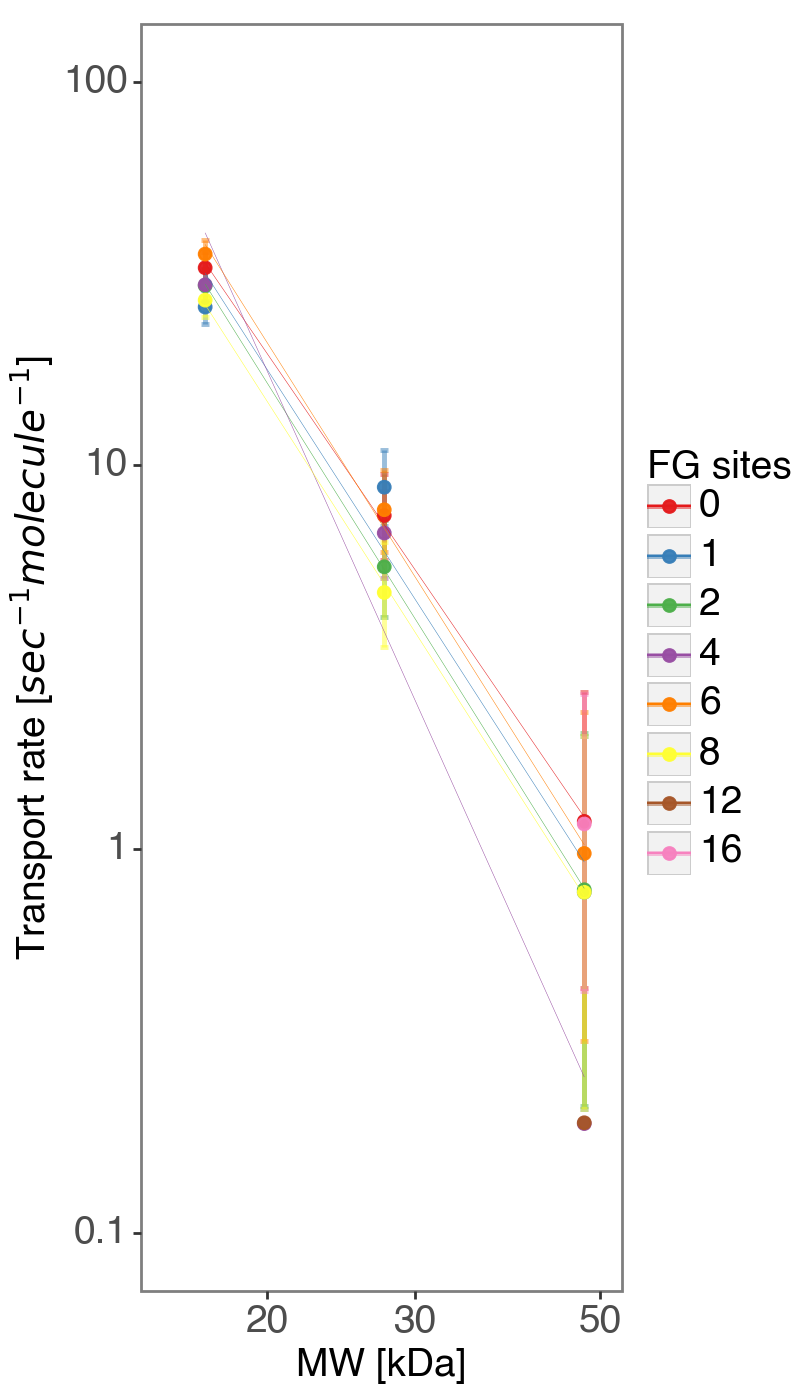

<Figure Size: (400 x 700)>

In [15]:
import plotnine as p9
import scipy.special
import numpy as np
   
is_to= np.isclose(df['to_sec'], 35e-6)
is_from= np.isclose(df['from_sec'], 5e-6)
is_small_inert= (df['type']=='inert') & (df['R']<25)
is_kap= (df['type']=='kap')
is_type= is_kap | is_small_inert
is_sites= df['n_sites']<17
slice= df[is_from & is_to & is_sites & is_small_inert]
p9.options.figure_size=(4,7)
aes= p9.aes(x='convert_radius_A_to_MW_kDa(R)+(n_sites_own-8)*0.03', 
                #y='transport_per_sec_per_particle+0.1',
#                          ymin='transport_per_sec_per_particle-1.96*transport_per_sec_per_particle_sem',
#                          ymax='transport_per_sec_per_particle+1.96*transport_per_sec_per_particle_sem',
            y=   'transport_per_sec_per_particle + 0.001',
            ymin='transport_per_sec_per_particle_95low',
            ymax='transport_per_sec_per_particle_95high',
            color='factor(n_sites)')
(p9.ggplot(data=slice,
           mapping=aes)
  + p9.geom_errorbar(size=1.0,
           alpha=0.5,
            width=0.01)
 + p9.geom_point(size=2,
           alpha=0.95)

#  + p9.xlab("radius [$A$]")
  + p9.xlab("MW [kDa]")
  + p9.ylab("Transport rate [$sec^{-1}molecule^{-1}$]")
  + p9.labs(color="FG sites")
 + p9.stat_smooth(method='lm',
      formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
     span=0.10,     se=False,     level=0.8,     size=0.1, alpha=0.2)
  + p9.scale_x_log10(limits=(15,50))
  + p9.scale_y_log10(limits=(0.1,100.0))
 + p9.scale_fill_brewer(type='qual', 
                         palette="Set1", 
                         aesthetics="color")  
 +p9.theme_bw()
 #+ p9.theme_xkcd()
 + p9.theme(text=p9.element_text(size=14),
             panel_grid=p9.element_blank())
)

#plt.show()

From 40.0 μs to 85.0 μs
From 40.0 μs to 85.0-100.0 μs


/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 11 rows containing missing values.


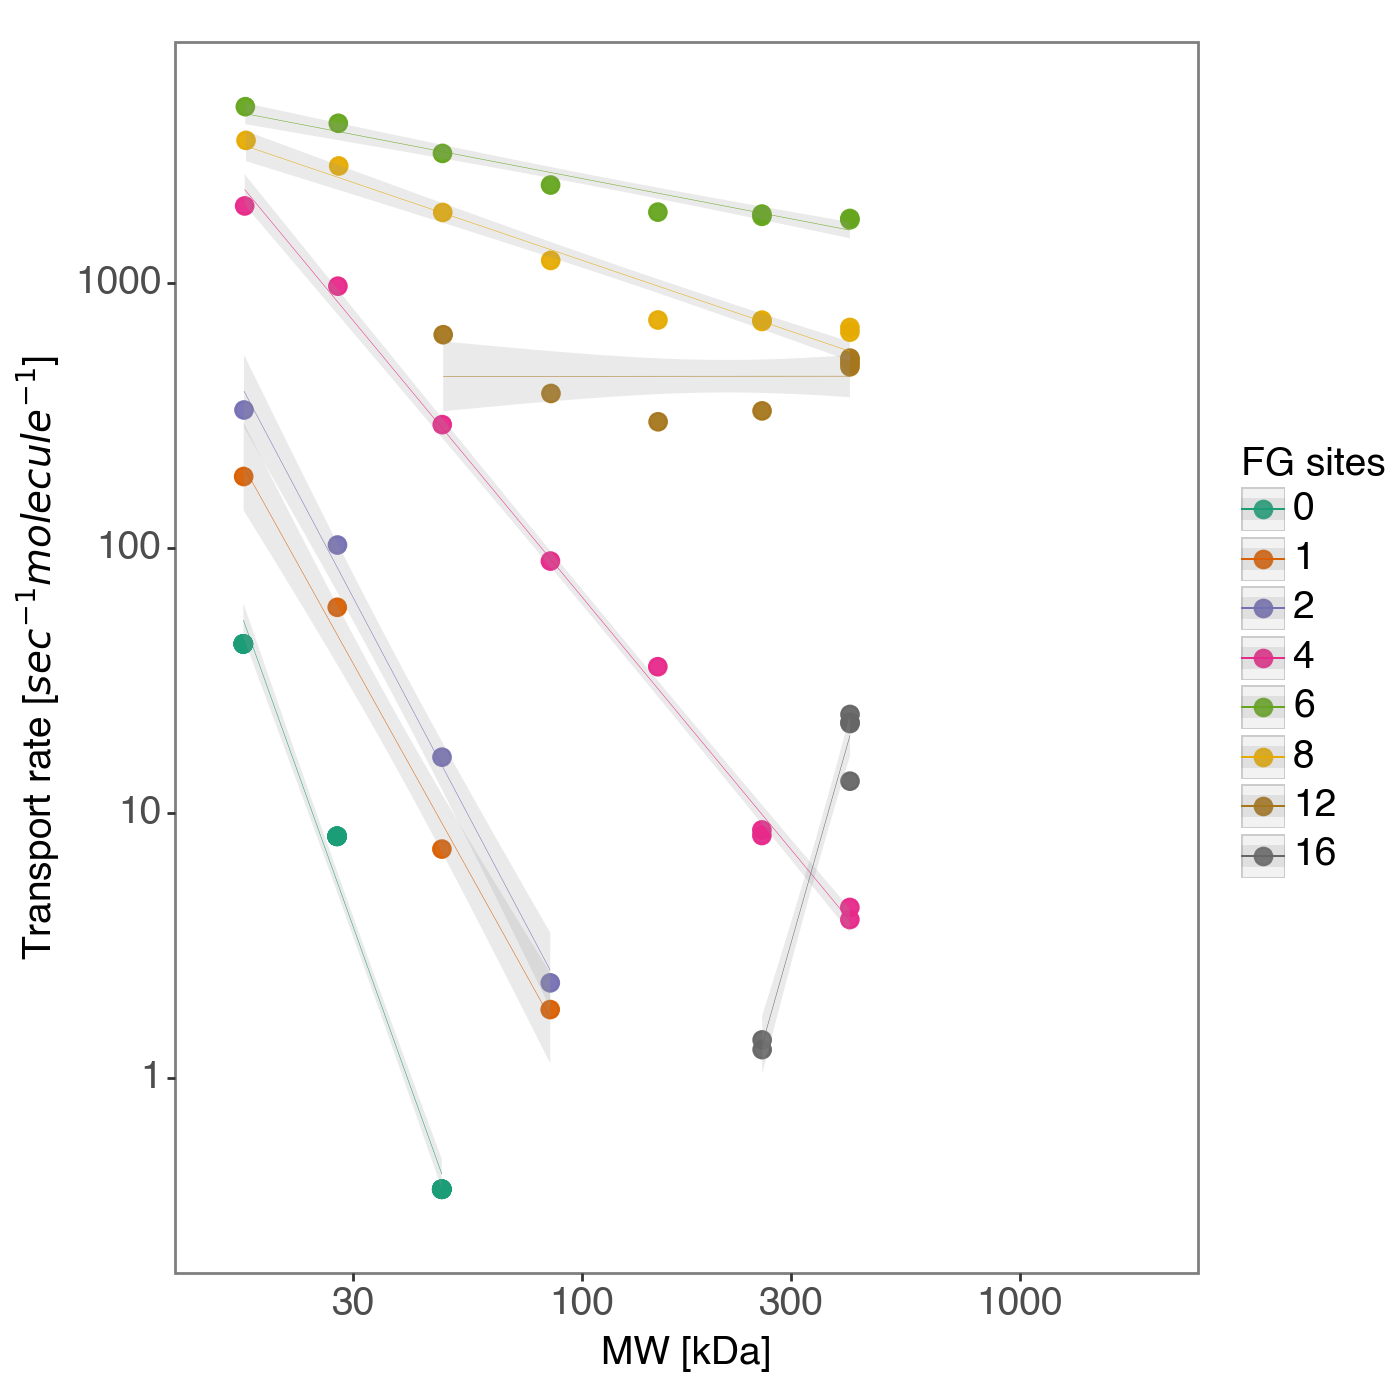

<Figure Size: (700 x 700)>

From 40.0 μs to 50.0 μs
From 40.0 μs to 50.0 μs


/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
/Users/barak/miniconda3/envs/py311/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 13 rows containing missing values.


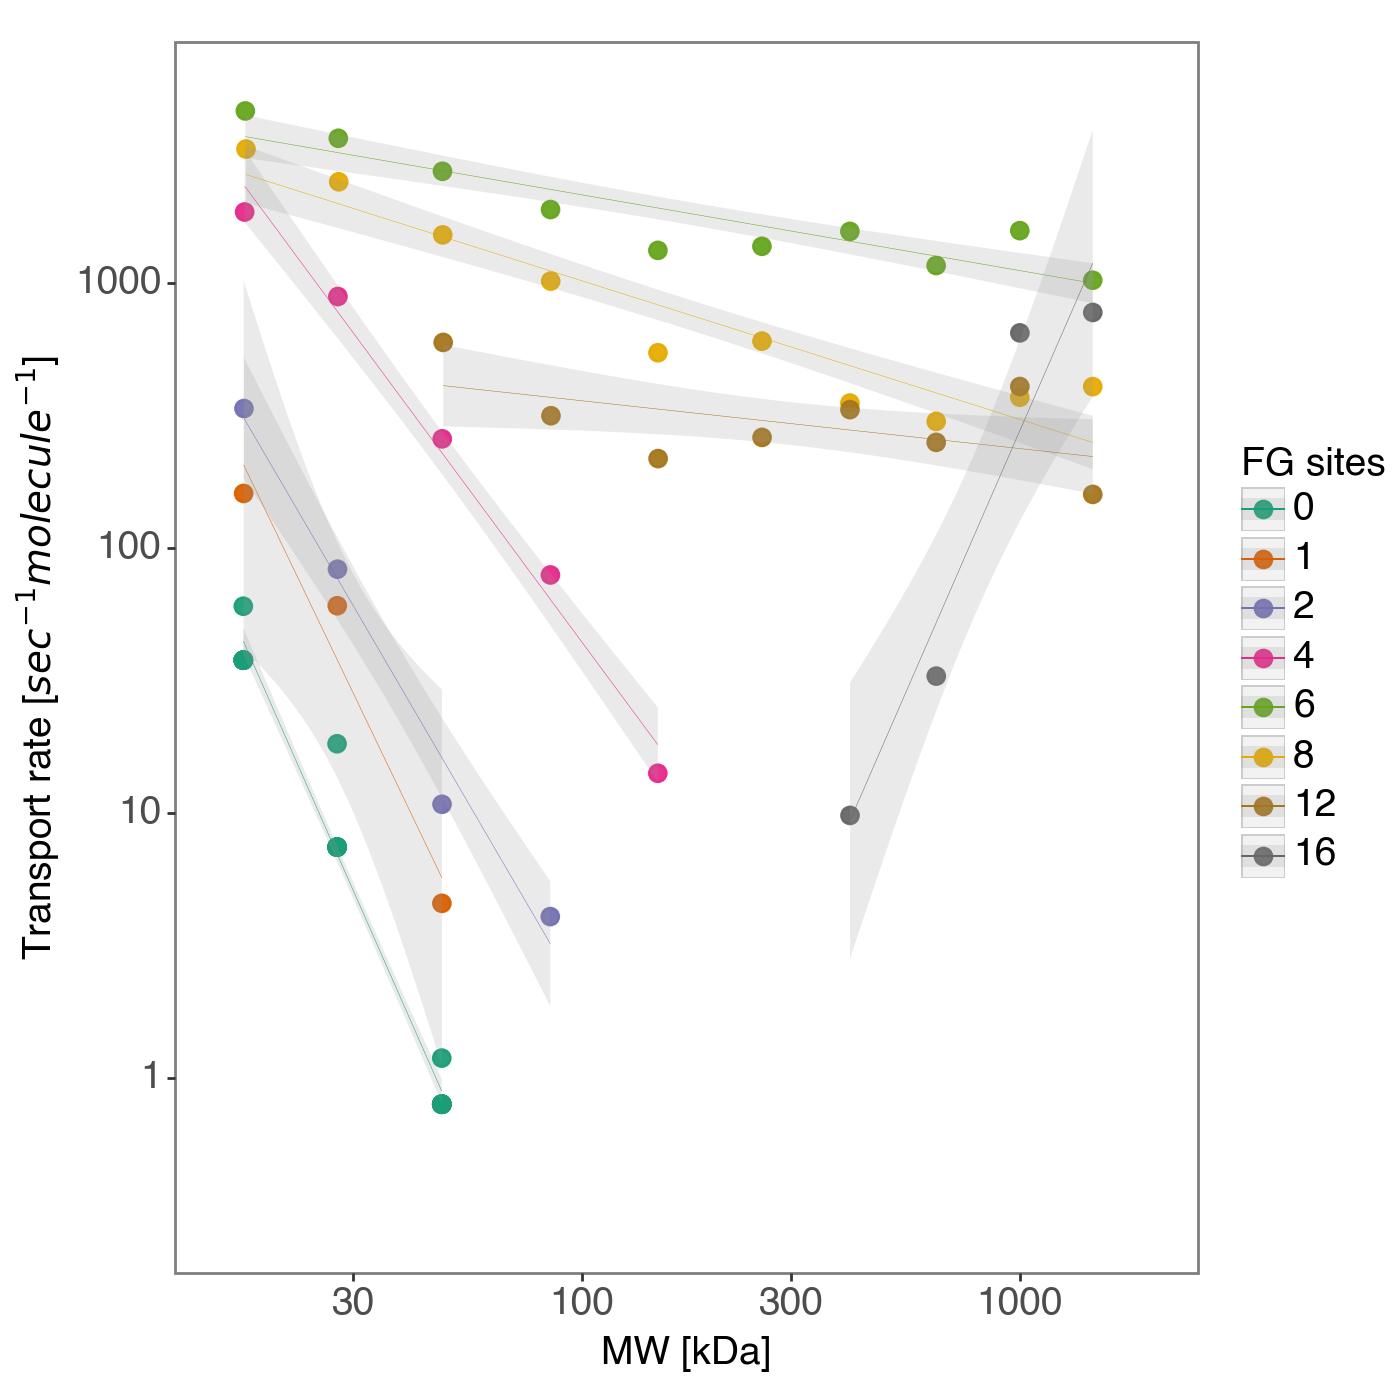

<Figure Size: (700 x 700)>

In [16]:
import plotnine as p9
import scipy.special
import numpy as np


def get_all_plot(df, from_sec, min_to_sec, max_to_sec=None):
    EPSILON=1e-15
    mu='\u03BC'
    if max_to_sec is None:
        max_to_sec= min_to_sec
    print(f"From {from_sec*1e6:.1f} {mu}s to {min_to_sec*1e6:.1f} {mu}s")
    if max_to_sec > min_to_sec:
        print(f"From {from_sec*1e6:.1f} {mu}s to {min_to_sec*1e6:.1f}-{max_to_sec*1e6:.1f} {mu}s")
    else:
        print(f"From {from_sec*1e6:.1f} {mu}s to {min_to_sec*1e6:.1f} {mu}s")
    is_from= np.isclose(df['from_sec'], from_sec)
    is_to= (df['to_sec'] > min_to_sec-EPSILON) & (df['to_sec'] < max_to_sec+EPSILON)
    is_small_inert= (df['type']=='inert') & (df['R']<29)
    is_kap= (df['type']=='kap')
    is_type= is_kap | is_small_inert
    is_sites= df['n_sites_own']<17
    slice= df[is_from & is_to & is_sites & is_type]
    p9.options.figure_size=(7,7)
    aes= p9.aes(x='convert_radius_A_to_MW_kDa(R)+(n_sites_own-8)*0.03', 
                    #y='transport_per_sec_per_particle+0.1',
    #                          ymin='transport_per_sec_per_particle-1.96*transport_per_sec_per_particle_sem',
    #                          ymax='transport_per_sec_per_particle+1.96*transport_per_sec_per_particle_sem',
                y=   'transport_per_sec_per_particle_r + 0.01',
                ymin='transport_per_sec_per_particle_r_95low',
                ymax='transport_per_sec_per_particle_r_95high',
                color='factor(n_sites_own)')
    return (p9.ggplot(data=slice,
               mapping=aes)
#      + p9.geom_errorbar(size=1.0,
#               alpha=0.5,
#                width=0.05)
     + p9.geom_point(size=3,
               alpha=0.95)

    #  + p9.xlab("radius [$A$]")
      + p9.xlab("MW [kDa]")
      + p9.ylab("Transport rate [$sec^{-1}molecule^{-1}$]")
      + p9.labs(color="FG sites")
     + p9.stat_smooth(method='lm',
          formula='y ~ np.exp(power(x))', #'y ~ np.log(x)',
         span=0.10,     se=True,     level=0.8,     size=0.1, alpha=0.2)
      + p9.scale_x_log10(limits=(15,2000.0))
      + p9.scale_y_log10(limits=(0.3,5000.0))
     + p9.scale_fill_brewer(type='qual', 
                             palette="Dark2",#"Dark2", 
                             aesthetics="color")  
     +p9.theme_bw()
#     + p9.theme_xkcd()
     + p9.theme(text=p9.element_text(size=14),
                 panel_grid=p9.element_blank())
    )

plot= get_all_plot(df, 40e-6, 85e-6, 100e-6)
display(plot)
plot= get_all_plot(df, 40e-6, 50e-6)
display(plot)